# JWST MIRI WFSS (P750L) — slitless spectral extraction example

<p style="text-align: right;"> <b>Fengwu Sun</b> (Harvard University &rarr; Westlake University)
    <br> Email: <a href = "mailto:sunfengwu@westlake.edu.cn">sunfengwu@westlake.edu.cn</a>
    <br> v1.0: June 2026</p>

This notebook and the reference data files are available in the GitHub repository: [github.com/fengwusun/miri_wfss](https://github.com/fengwusun/miri_wfss)

This notebook processes **JWST MIRI P750L FULL-array slitless ("WFSS") rate files** into flux-calibrated 2D and 1D spectra (4.7–13.8 µm), using the `MIRI_WFSS_CAL_v1.0` calibration suite shipped in this repository (`data/cal_v1.1/`).

When the MIRI LRS prism (P750L) is used without the slit on the FULL imager array, every source in the illuminated field produces a dispersed spectral trace — effectively providing wide-field slitless spectroscopy in the mid-infrared. For more information, please see the JWST user documentation of [MIRI LRS](https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-observing-modes/miri-low-resolution-spectroscopy) and [MIRI WFSS](https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-observing-modes/miri-wide-field-slitless-spectroscopy).

![MIRI imager field of view and filter wheel](media/miri_aperture_filter_wheel.jpg)

<p><i><b>Left</b>: the MIRI imager FULL array (74″ × 113″), with the LRS slit, the LRS slitless subarray and target-acquisition regions, and the coronagraphic fields on the left strip; the color bars indicate the P750L dispersion direction (5 → 14 µm, running along detector −y). <b>Right</b>: the MIRI imager filter wheel with the P750L (LRS) prism highlighted — and keep in mind that MIRI LRS was designed for optimizing exoplanet science, not wide-field surveys. Figures taken from the [JWST User Documentation](https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument).</i></p>

As of this writing (June 2026), several JWST GO and CAL programs — including but not limited to GO-3224, GO-4192, GO-4762, GO-8544, and CAL-9505 — have observed with the MIRI P750L prism in this mode. This notebook offers an executable pipeline example that extracts MIRI P750L spectra over the MIRI imager FoV, independent of the official calibration efforts of the STScI team. The pipeline implements the full workflow:

1. download the example data (GO-4192, PI: Stacey Alberts; GOODS-N) directly from MAST;
2. inspect a raw P750L FULL frame;
3. calibrate rate &rarr; "lv1.5": flat-field + master-sky subtraction;
4. attach a celestial WCS (`jwst` `AssignWcsStep` in imaging mode);
5. load the source catalog and check footprint coverage;
6. rectify a dispersed trace using the v2.1 trace + wavelength polynomials;
7. flux-calibrate with the v2 response fR(λ);
8. co-add exposures (PA grouping + sigma-clipped weighted mean);
9. extract 1D spectra (boxcar and optimal/Horne);
10. produce atlas-style figures and machine-readable spectra for the whole catalog;
11. caveats & tips.

This notebook shares a workflow very similar to the one prepared for [NIRCam grism WFSS](https://github.com/fengwusun/nircam_grism), which has been used to process many NIRCam WFSS programs since 2022.

The calibration model, its derivation, and its validation will be fully described in **Sun (2026)** (see the repository README for the citation). As of June 2026, this MIRI WFSS calibration has reached the following accuracy: trace MAD 0.055 px; wavelength 220–610 km/s RMS (0.1–0.25 resolution element, 7.9–13.1 µm); flux ~1–2% absolute at 7.4–13.8 µm (CALSPEC-direct) and ~5% shape at 4.7–7.4 µm (stellar-ensemble, overlap-tied).

**Python Requirements**: `numpy`, `scipy`, `astropy`, `matplotlib`, and `jwst` (only for the WCS step, with a CRDS connection on first run). Everything is available in a standard [`stenv`](https://stenv.readthedocs.io/) environment. Run this notebook from the repository root.

## Step 0 — Setup

Imports, CRDS environment, repository paths, and the MIRI WFSS detector constants.

**Note**: The CRDS variables must be set **before** importing anything from `jwst`; if you already have `CRDS_PATH`/`CRDS_SERVER_URL` configured, your settings are kept. On the first run, the WCS step (step 4) will download a few MIRI imaging reference files (~100 MB) into the CRDS cache.

Detector geometry (see `data/cal_v1.1/README.md`): the P750L-dispersed, illuminated "WFSS" region of the FULL array is roughly `x = 387 – 1020`, `y = 15 – 1017` (the area to the left is occupied by the coronagraph subarrays). Dispersion runs along detector **y**: a source at direct-imaging position ($x_0$, $y_0$) produces a spectral trace ($x_s$, $y_s$) from $dy_s$ ≈ +150 px (blue end) down to $dy_s$ ≈ −262 px (red end), with a small wavelength-dependent tilt $dx_s(dy_s)$ of a few pixels.

In [1]:
import os, glob, subprocess, warnings
from pathlib import Path
from multiprocessing import Pool

'''
##################################################################
CRDS configuration — must be set BEFORE importing any jwst module
##################################################################
'''
os.environ.setdefault('CRDS_SERVER_URL', 'https://jwst-crds.stsci.edu')
os.environ.setdefault('CRDS_PATH', str(Path.home() / 'crds_cache'))

import numpy as np
from astropy.io import fits, ascii
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy import wcs as awcs
from astropy.stats import mad_std, sigma_clipped_stats
from scipy import ndimage, interpolate
from scipy.ndimage import binary_dilation

import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'sans-serif',
                     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
                     'font.size': 12, 'axes.titlesize': 13,
                     'axes.labelsize': 12.5, 'legend.fontsize': 10})

# --- repository layout (run the notebook from the repo root) ---------------
CAL_DIR  = Path('data/cal_v1.1')                          # calibration suite (committed)
RATE_DIR = Path('data/rates')                             # example rate files (downloaded)
CAT_PATH = Path('data/catalogs/goodsn_example_sources.csv')
PRODUCTS = Path('products')                               # notebook outputs
PRODUCTS.mkdir(exist_ok = True)

# --- MIRI WFSS detector constants -------------------------------------------
WFSS_X = (387, 1020)          # illuminated WFSS region, detector x [px]
WFSS_Y = (15, 1017)           # illuminated WFSS region, detector y [px]
DY_MIN, DY_MAX = -262, +150   # trace extent around the direct position [px]
XHALF   = 26                  # half width of the rectified cutout [px]
AP_HALF = 10                  # half width of the extraction window [px]
MARGIN_X, MARGIN_Y = XHALF, 25  # footprint margins: the cutout must stay illuminated
PIX_MIRI = 0.11               # arcsec per MIRI pixel
WGRID = np.arange(4.6, 13.8, 0.01)   # common wavelength grid for co-adds [um]

# jwst DQ bits used below
DO_NOT_USE = 1; SATURATED = 2; NON_WFSS_BIT = 128

print('setup OK; products ->', PRODUCTS.resolve())

setup OK; products -> /Users/sunfengwu/Documents/miri_wfss/products


## Step 1 — Download the example data

The example dataset is from **GO-4192** (PI: S. Alberts; GOODS-N): observation 3
(2024-05-20) and its repeat, observation 103 (2025-05-17) — together **8 × 364 s P750L
FULL exposures** (~170 MB) pointed at a group of bright PAH-emitting galaxies around
(RA, Dec) ≈ (189.11°, +62.21°). In the archive these carry `EXP_TYPE = MIR_LRS-FIXEDSLIT`
(the dedicated `MIR_WFSS` label only exists for newer calibration programs), `FILTER =
P750L`, `SUBARRAY = FULL`.

The shell script `download_goodsn_example_rates.sh` fetches the files directly from MAST
(public data, no token needed). The cell below runs it only if the files are not already
in `data/rates/`.

In [2]:
rate_files = sorted(RATE_DIR.glob('jw*_mirimage_rate.fits'))
if len(rate_files) < 8:
    print('Example data not found locally — downloading from MAST (~170 MB) ...')
    subprocess.run(['sh', 'download_goodsn_example_rates.sh'], check = True)
    rate_files = sorted(RATE_DIR.glob('jw*_mirimage_rate.fits'))

for f in rate_files:
    h = fits.getheader(f, 0)
    print(f"{f.name}   {h['EXP_TYPE']:19s} {h['FILTER']:6s} {h['SUBARRAY']:5s} "
          f"{h['DATE-OBS']}  {h['EFFEXPTM']:5.0f} s")
print(f'\n{len(rate_files)} exposures, {sum(f.stat().st_size for f in rate_files)/1e6:.0f} MB')

jw04192003001_02101_00001_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2024-05-20    364 s
jw04192003001_02101_00002_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2024-05-20    364 s
jw04192003001_02103_00001_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2024-05-20    364 s
jw04192003001_02103_00002_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2024-05-20    364 s
jw04192103001_03103_00001_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2025-05-17    364 s
jw04192103001_03103_00002_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2025-05-17    364 s
jw04192103001_03105_00001_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2025-05-17    364 s
jw04192103001_03105_00002_mirimage_rate.fits   MIR_LRS-FIXEDSLIT   P750L  FULL  2025-05-17    364 s

8 exposures, 170 MB


## Step 2 — Inspect a raw P750L FULL frame

A raw rate frame is dominated by the bright, spatially structured mid-IR sky (zodiacal + telescope thermal emission) dispersed through the prism — the sky itself is a slitless source filling the field. Galaxy traces are the faint vertical streaks on top of it. The <span style="color:cyan;">cyan contour</span> marks the illuminated WFSS region from `region_mask_P750L.fits`; the region to its left holds the (4QPM + Lyot) coronagraph fields, which see no prism light.

The right panel zooms on the trace of the brightest catalog source (JADES-GN-1092837, F444W = 18.2 AB; see [JADES GOODS-N FitsMap of the galaxy](https://slate.ucsc.edu/~brant/jades/GOODS-N/v1.0/current/map/?ra=189.1435823&dec=62.2035182&zoom=9)): dispersion runs along y (top = blue end, bottom = red end).

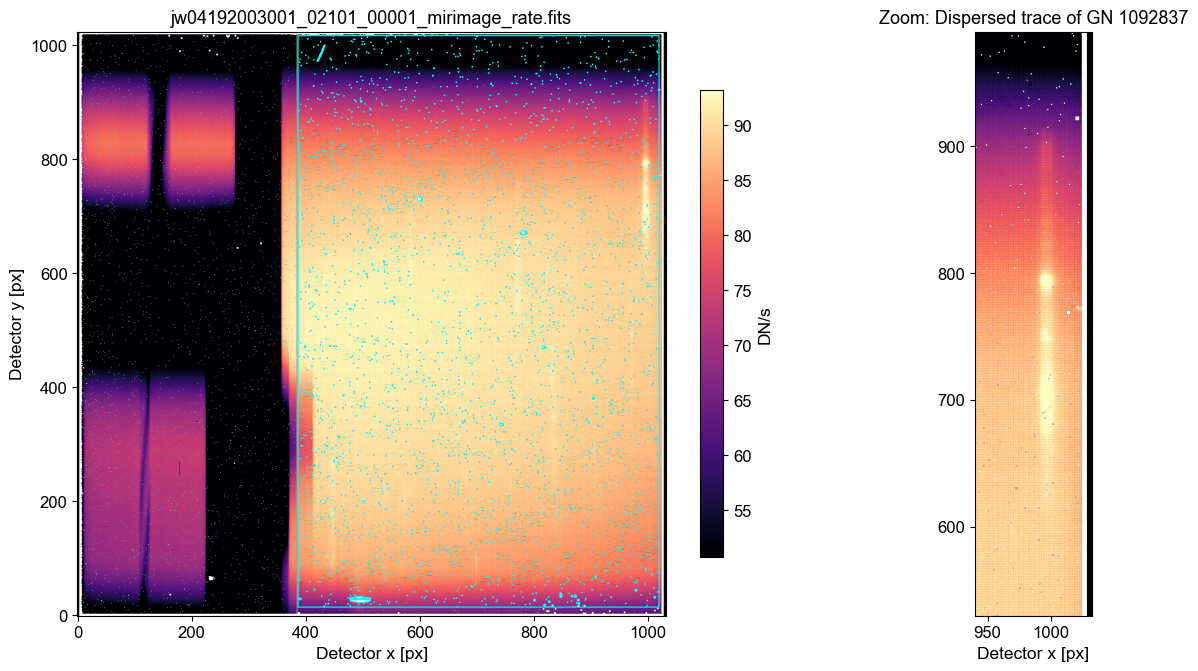

In [3]:
demo_rate = RATE_DIR / 'jw04192003001_02101_00001_mirimage_rate.fits'
with fits.open(demo_rate) as h:
    sci_raw = h['SCI'].data.astype(float)

region  = fits.getdata(CAL_DIR / 'region_mask_P750L.fits', 'REGION')
in_wfss = region == 1

fig, axes = plt.subplots(1, 2, figsize = (13.0, 6.6), width_ratios = [1.35, 1],
                         constrained_layout = True)
v = np.nanpercentile(sci_raw[in_wfss], [5, 99])
im = axes[0].imshow(sci_raw, origin = 'lower', cmap = 'magma', vmin = v[0], vmax = v[1])
axes[0].contour(in_wfss, levels = [0.5], colors = 'cyan', linewidths = 0.8)
axes[0].set(title = demo_rate.name, xlabel = 'Detector x [px]', ylabel = 'Detector y [px]')
fig.colorbar(im, ax = axes[0], label = 'DN/s', shrink = 0.8)

axes[1].imshow(sci_raw, origin = 'lower', cmap = 'magma', vmin = v[0], vmax = v[1])
axes[1].set(xlim = (940, 1032), ylim = (530, 990), xlabel = 'Detector x [px]',
            title = 'Zoom: Dispersed trace of GN 1092837')
plt.show()

## Step 3 — rate → lv1.5: flat field + master-sky subtraction

We call the calibrated frame "**lv1.5**" — past level 1 (`rate`), but not the standard
level-2 pipeline (which cannot process these exposures). The background model (sky v5)
has three stages, all in DN/s:

* **Flat field** — `flat_P750L_F560W.fits`, which is built upon the F560W *imaging* flat. A pixel-area / detector response flat is (roughly) the correct first-order correction for slitless data because every pixel sees a (different) blend of wavelengths; the residual color terms are absorbed by the response $fR(\lambda)$ and validated by the L-flat (roughly = 1, step 7).

* **Additive defect map** — the `ADDITIVE` extension of `master_sky_P750L_v5.fits` maps additive detector artifacts (in DN/s, derived from a 304-frame consensus-residual regression). It is subtracted from the flat-fielded frame **unscaled**, before the sky scale fit; pixels with |ADDITIVE| > 0.5 DN/s are additionally flagged `DO_NOT_USE`.

* **Master sky** — the `SKY` extension of `master_sky_P750L_v5.fits`, a consensus-patched sigma-clipped stack of archival FULL P750L frames. Per exposure we fit a single scale factor (the sky level varies with ecliptic position and epoch, its *shape* much less) and subtract: `residual = sci/flat − additive − scale × sky`. The scale is `nanmedian(sci_flat / sky)` over valid WFSS pixels, iterated 3× while masking detected sources (|residual| > 4 × MAD-RMS, dilated 5 px) so bright traces do not bias the sky level. This master background subtraction method is defined as "**mode A**" throughout this pipeline.

* **Per-row de-banding** — finally, a sigma-clipped median computed from the source-masked WFSS pixels of each detector row is removed (rows with <50 background pixels inherit interpolated offsets from their neighbours). This suppresses EMI banding and residual row-wise sky gradients that a single scaled template cannot follow.

An optional "**mode B**" replaces the single-scale sky fit with the 5 leading PCA components of the residual sky variation (`eigen_skies_v5_P750L.fits`); it helps frames with unusual sky gradients (see the optional cell below).

sky scale  = 87.7727
residual MAD-RMS = 0.3327 DN/s   (median pipeline ERR = 0.2318)
source-masked fraction of the WFSS region = 0.223


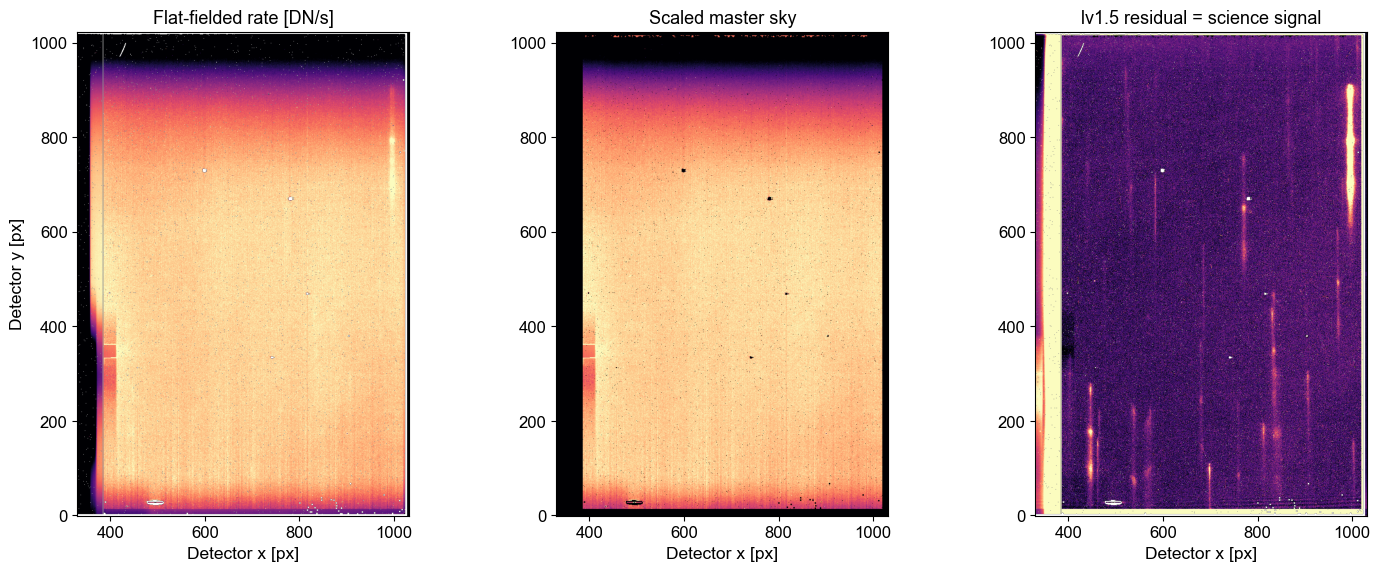

In [4]:
SKY_PATH = CAL_DIR / 'master_sky_P750L_v5.fits'
FLAT = fits.getdata(CAL_DIR / 'flat_P750L_F560W.fits', 'FLAT').astype(np.float32)
SKY  = fits.getdata(SKY_PATH, 'SKY').astype(np.float32)
try:                       # v5+: additive defect map (DN/s, flat-fielded frame)
    ADD_MAP = fits.getdata(SKY_PATH, 'ADDITIVE').astype(np.float32)
except KeyError:
    ADD_MAP = None
FLAT_SAFE = np.where(np.isfinite(FLAT), FLAT, 1.0)


def flat_sky_subtract(sci, err, dq, vp, vr, mode = 'A', eigen_full = None):
    """Flat-field a P750L FULL rate frame and subtract the background (sky v5).

    Stages: (1) divide by the flat; (2) subtract the additive defect map,
    unscaled; (3) subtract the scaled master sky —
      mode='A': residual = sci/flat - additive - scale * sky   (scale iterated,
                source-masked)
      mode='B': sky model = c0 * sky + sum_k c_k * eigen_k   (5 PCA components)
    — and (4) remove a sigma-clipped median from every detector row
    (source-masked WFSS pixels; EMI de-banding).

    sci, err, dq : SCI / ERR / DQ arrays of one rate exposure
    vp, vr       : VAR_POISSON / VAR_RNOISE arrays (see read_rate)
    mode         : 'A' = scaled master sky (default); 'B' = + 5 PCA components
    eigen_full   : (5, 1024, 1032) PCA basis, required only for mode 'B' 

    Returns a dict with the calibrated arrays, the sky model, the source mask,
    provenance keywords, and residual statistics.
    """
    sci_fc = sci / FLAT_SAFE
    if ADD_MAP is not None:
        sci_fc = sci_fc - ADD_MAP
    err_fc = err / FLAT_SAFE
    vp_fc  = vp  / FLAT_SAFE**2
    vr_fc  = vr  / FLAT_SAFE**2

    valid_dq = (dq & (DO_NOT_USE | SATURATED)) == 0
    valid = valid_dq & in_wfss & np.isfinite(sci_fc) & np.isfinite(FLAT) & np.isfinite(SKY)
    if valid.sum() < 1000:
        raise ValueError('too few valid pixels')

    # seed source mask from a first-pass residual
    scale = float(np.nanmedian(sci_fc[valid] / SKY[valid]))
    residual_init = sci_fc - scale * SKY
    rmad = mad_std(residual_init[valid])
    src = (np.abs(residual_init) > 3.0 * rmad) & in_wfss
    src = binary_dilation(src, iterations = 5)

    if mode == 'A':
        for it in range(3):
            fit = valid & ~src
            if fit.sum() < 100:
                break
            scale = float(np.nanmedian(sci_fc[fit] / SKY[fit]))
            resid = sci_fc - scale * SKY
            rmad  = mad_std(resid[fit])
            new_src = (np.abs(resid) > 4.0 * rmad) & in_wfss
            new_src = binary_dilation(new_src, iterations = 5)
            grow = (new_src & ~src).sum()
            src = src | new_src
            if grow < 100:
                break
        sky_model = scale * SKY
        prov = {'SKYMODEL': 'A: scale * master_sky_v5', 'SKYSCALE': float(scale)}
    else:                                   # mode B: master sky + 5 PCA components
        coefs = None
        for it in range(5):
            fit = valid & ~src
            if fit.sum() < 100:
                break
            A = np.column_stack([SKY[fit]] + [eigen_full[k][fit] for k in range(5)])
            y = sci_fc[fit]
            keep = np.isfinite(y) & np.all(np.isfinite(A), axis = 1)
            coefs, *_ = np.linalg.lstsq(A[keep], y[keep], rcond = None)
            sky_model = coefs[0] * SKY
            for k in range(5):
                sky_model = sky_model + coefs[k + 1] * eigen_full[k]
            resid = sci_fc - sky_model
            rmad  = mad_std(resid[fit])
            new_src = (np.abs(resid) > 4.0 * rmad) & in_wfss
            new_src = binary_dilation(new_src, iterations = 5)
            grow = (new_src & ~src).sum()
            src = src | new_src
            if grow < 200:
                break
        prov = {'SKYMODEL': 'B: sky + 5 PCA', 'SKYSCALE': float(coefs[0])}
        for k in range(5):
            prov[f'SKYCOEF{k+1}'] = float(coefs[k + 1])

    sky_model = sky_model.copy()
    sky_model[~in_wfss] = 0
    residual = sci_fc - sky_model

    # per-row sigma-clipped median removal within the WFSS region (v5):
    # suppresses EMI banding and residual row-wise sky gradients that a single
    # scaled template cannot follow; rows with too few background pixels
    # inherit the interpolated offset of their neighbours
    bg = np.where(valid & ~src & in_wfss, residual, np.nan)
    sub = bg[:, WFSS_X[0]:WFSS_X[1]]
    nbg = np.sum(np.isfinite(sub), axis = 1)
    row_off = np.full(residual.shape[0], np.nan, np.float32)
    for y in np.where(nbg >= 50)[0]:
        row_off[y] = sigma_clipped_stats(sub[y][np.isfinite(sub[y])],
                                         sigma = 3.0, maxiters = 3)[1]
    yr = np.arange(WFSS_Y[0], WFSS_Y[1])
    good_y = np.isfinite(row_off[yr])
    if good_y.sum() > 10:
        row_full = np.interp(yr, yr[good_y], row_off[yr][good_y])
        corr = np.zeros(residual.shape[0], np.float32)
        corr[yr] = row_full
        residual = residual - corr[:, None]
        prov['ROWMED'] = (float(np.nanmedian(np.abs(row_full))),
                          'median |per-row clipped-median| removed')

    new_dq = dq.copy()
    new_dq[~in_wfss] |= NON_WFSS_BIT
    new_dq[~np.isfinite(FLAT)] |= DO_NOT_USE
    if ADD_MAP is not None:
        new_dq[np.abs(ADD_MAP) > 0.5] |= DO_NOT_USE

    measure = valid & ~src
    stats = dict(MADRMS = float(mad_std(residual[measure])),
                 MEDERR = float(np.nanmedian(err_fc[measure])),
                 SRCFRAC = float(src.sum() / in_wfss.sum()))
    return dict(residual = residual, err = err_fc, dq = new_dq, vp = vp_fc, vr = vr_fc,
                sky_model = sky_model, src_mask = src, prov = prov, stats = stats)


def read_rate(path):
    """Read SCI/ERR/DQ/VAR_* from a rate file (with fallbacks).

    path : *_rate.fits file path
    """
    with fits.open(path) as h:
        primary = h[0].header.copy()
        sci = h['SCI'].data.astype(np.float32)
        err = h['ERR'].data.astype(np.float32)
        dq  = h['DQ'].data.astype(np.uint32) if 'DQ' in h else np.zeros_like(sci, np.uint32)
        try:
            vp = h['VAR_POISSON'].data.astype(np.float32)
        except KeyError:
            vp = err**2
        try:
            vr = h['VAR_RNOISE'].data.astype(np.float32)
        except KeyError:
            vr = np.zeros_like(err)
    return primary, sci, err, dq, vp, vr


primary, sci, err, dq, vp, vr = read_rate(demo_rate)
calA = flat_sky_subtract(sci = sci, err = err, dq = dq, vp = vp, vr = vr, mode = 'A')
s = calA['stats']
print(f"sky scale  = {calA['prov']['SKYSCALE']:.4f}")
print(f"residual MAD-RMS = {s['MADRMS']:.4f} DN/s   (median pipeline ERR = {s['MEDERR']:.4f})")
print(f"source-masked fraction of the WFSS region = {s['SRCFRAC']:.3f}")

fig, axes = plt.subplots(1, 3, figsize = (14.5, 5.6), constrained_layout = True)
v = np.nanpercentile(sci[in_wfss] / FLAT_SAFE[in_wfss], [5, 99])
axes[0].imshow(sci / FLAT_SAFE, origin = 'lower', cmap = 'magma', vmin = v[0], vmax = v[1])
axes[0].set_title('Flat-fielded rate [DN/s]')
axes[1].imshow(calA['sky_model'], origin = 'lower', cmap = 'magma', vmin = v[0], vmax = v[1])
axes[1].set_title('Scaled master sky')
r = calA['residual']
vr_ = np.nanpercentile(r[in_wfss], [2, 99.5])
axes[2].imshow(r, origin = 'lower', cmap = 'magma', vmin = vr_[0], vmax = vr_[1])
axes[2].set_title('lv1.5 residual = science signal')
for ax in axes:
    ax.set(xlim = (330, 1032), xlabel = 'Detector x [px]')
axes[0].set_ylabel('Detector y [px]')
plt.show()

**Optional — mode B (PCA sky residuals).** The leading PCA components (we use 5 of the
20 shipped) capture the epoch-to-epoch variation of the sky *shape* (mostly a slow
gradient along the dispersion direction). The v5 basis is outlier-patched against an
along-row running median, so compact imprints of imperfectly masked sources cannot be
stamped into corrected frames; still, if you use mode B, difference the result against
its mode-A counterpart before trusting compact faint sources. Mode B usually lowers the
residual RMS by a few per cent at most; the example atlas and the v1.0 validation all
use mode A. Demonstrated here on the same exposure:

In [5]:
eig = fits.getdata(CAL_DIR / 'eigen_skies_v5_P750L.fits', 'COMPONENTS')[:5]
eigen_full = np.zeros((5, 1024, 1032), dtype = np.float32)   # embed WFSS-region cutouts
for k in range(5):
    eigen_full[k, WFSS_Y[0]:WFSS_Y[1], WFSS_X[0]:WFSS_X[1]] = eig[k]

calB = flat_sky_subtract(sci = sci, err = err, dq = dq, vp = vp, vr = vr,
                         mode = 'B', eigen_full = eigen_full)
coef_str = ', '.join(f"{v:+.4f}" for k, v in calB['prov'].items()
                     if k.startswith('SKYCOEF'))
print(f"mode A: residual MAD-RMS = {calA['stats']['MADRMS']:.4f} DN/s")
print(f"mode B: residual MAD-RMS = {calB['stats']['MADRMS']:.4f} DN/s "
      f"(PCA coefficients: {coef_str})")
del calB, eigen_full, eig

mode A: residual MAD-RMS = 0.3327 DN/s
mode B: residual MAD-RMS = 0.3334 DN/s (PCA coefficients: +181.4001, +80.5669, +107.8789, -2.6514, -22.4611)


## Step 4 — Attach a celestial WCS and write the lv1.5 files

To locate catalog sources on the detector we need a celestial WCS, but CRDS has no distortion reference keyed to the slitless P750L exposure types. Therefore, we can temporarily relabel the exposure as `MIR_IMAGE`, run the `jwst` `AssignWcsStep` (which then picks up the MIRI **imager** distortion — the correct optical path for the direct position), restore the original `EXP_TYPE`, and merge the resulting (SIP-approximated) FITS WCS into the lv1.5 `SCI` header.

The cell below combines steps 3+4 and writes one `*_rate_lv1.5.fits` per exposure into `products/`, with extensions `SCI` (sky-subtracted, WCS-carrying), `ERR`, `DQ`, `VAR_POISSON`, `VAR_RNOISE`, `SKY_MODEL`, `REGION`, `SRC_MASK` (+ the `jwst` `ASDF` extension). The cell rewrites the lv1.5 files on every run. On the first run, CRDS downloads the MIRI imaging references (~100 MB); afterwards this takes ~10–20 s per exposure.

**Bulk / parallel processing**: the per-exposure work is wrapped in `make_lv15_one()`, run serially by default; the commented lines show the `multiprocessing.Pool` variant with `n_proc` processes (the same pattern as the [NIRCam grism notebook](https://github.com/fengwusun/nircam_grism)). Use it on Linux for large programs — mind the RAM (~2 GB per process), and populate a fresh CRDS cache with one serial run first so parallel workers do not race the downloads. On macOS/Windows the default process start method cannot run notebook-defined functions in a `Pool`, and forcing `fork` can deadlock inside `jwst` (we tested) — keep the serial loop there, or move the functions into a `.py` module and parallelize from a script.

In [6]:
def attach_imaging_wcs(rate_path):
    """Run jwst AssignWcsStep in imaging mode; return (SCI header, ASDF HDU).

    rate_path : *_rate.fits file path
    """
    import tempfile
    from jwst.assign_wcs import AssignWcsStep
    from jwst import datamodels

    with datamodels.open(str(rate_path)) as model_in:
        orig_exp_type = model_in.meta.exposure.type
        model_in.meta.exposure.type = 'MIR_IMAGE'    # CRDS-acceptable for distortion lookup
        wcs_model = AssignWcsStep.call(model_in, save_results = False)
        wcs_model.meta.exposure.type = orig_exp_type

    with tempfile.TemporaryDirectory() as td:
        tmp_path = Path(td) / 'wcs_tmp.fits'
        wcs_model.save(str(tmp_path))
        with fits.open(tmp_path) as h_tmp:
            wcs_header = h_tmp['SCI'].header.copy()
            asdf_ext = None
            if 'ASDF' in [e.name for e in h_tmp]:
                asdf_ext = fits.BinTableHDU(data = h_tmp['ASDF'].data,
                                            header = h_tmp['ASDF'].header, name = 'ASDF')
    del wcs_model
    return wcs_header, asdf_ext


def make_lv15(rate_path, out_path, mode = 'A'):
    """rate -> lv1.5: flat + sky calibration (step 3) + celestial WCS (step 4).

    rate_path : input *_rate.fits exposure
    out_path  : output *_rate_lv1.5.fits path (overwritten if present)
    mode      : background mode passed to flat_sky_subtract()
    """
    wcs_header, asdf_ext = attach_imaging_wcs(rate_path)
    primary, sci, err, dq, vp, vr = read_rate(rate_path)
    cal = flat_sky_subtract(sci = sci, err = err, dq = dq, vp = vp, vr = vr,
                            mode = mode)

    prim = fits.PrimaryHDU(header = primary)
    prim.header['LV1P5']    = 'flat-corrected, sky-subtracted'
    prim.header['FLATFROM'] = 'flat_P750L_F560W.fits'
    prim.header['SKYFROM']  = 'master_sky_P750L_v5.fits'
    for k, v in cal['prov'].items():
        prim.header[k] = v
    if ADD_MAP is not None:
        prim.header['ADDMAP'] = (int(np.sum(np.abs(ADD_MAP) > 0)),
                                 'px corrected by additive defect map')
    prim.header['MADRMS']  = (cal['stats']['MADRMS'], 'MAD-RMS residual, source-masked WFSS')
    prim.header['MEDERR']  = (cal['stats']['MEDERR'], 'Median ERR, same region')
    prim.header['SRCFRAC'] = (cal['stats']['SRCFRAC'], 'fraction WFSS as source')

    sci_hdu = fits.ImageHDU(cal['residual'].astype(np.float32), name = 'SCI')
    for k, v in wcs_header.items():           # merge the WCS-assigned header
        if k in ('XTENSION', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2',
                 'PCOUNT', 'GCOUNT', 'EXTNAME', 'INHERIT'):
            continue
        try:
            sci_hdu.header[k] = (v, wcs_header.comments[k])
        except Exception:
            sci_hdu.header[k] = v

    hdus = [prim, sci_hdu,
            fits.ImageHDU(cal['err'].astype(np.float32),       name = 'ERR'),
            fits.ImageHDU(cal['dq'].astype(np.uint32),         name = 'DQ'),
            fits.ImageHDU(cal['vp'].astype(np.float32),        name = 'VAR_POISSON'),
            fits.ImageHDU(cal['vr'].astype(np.float32),        name = 'VAR_RNOISE'),
            fits.ImageHDU(cal['sky_model'].astype(np.float32), name = 'SKY_MODEL'),
            fits.ImageHDU(region,                              name = 'REGION'),
            fits.ImageHDU(cal['src_mask'].astype(np.uint8),    name = 'SRC_MASK')]
    if asdf_ext is not None:
        hdus.append(asdf_ext)
    fits.HDUList(hdus).writeto(out_path, overwrite = True)
    return cal['stats']


import logging
for name in ('stpipe', 'jwst', 'CRDS'):       # keep the notebook readable
    logging.getLogger(name).setLevel(logging.ERROR)

def make_lv15_one(f):
    """rate -> lv1.5 for one exposure (also Pool-friendly for bulk runs).

    f : input *_rate.fits path; the lv1.5 file is written under products/
    """
    out = PRODUCTS / f.name.replace('_rate.fits', '_rate_lv1.5.fits')
    print(f'{f.name}: calibrating + attaching WCS '
          '(CRDS may download references on first run) ...')
    st = make_lv15(rate_path = f, out_path = out, mode = 'A')
    print(f"   -> {out.name}: MAD-RMS {st['MADRMS']:.4f} DN/s, "
          f"src frac {st['SRCFRAC']:.3f}")
    return out


n_proc = 4    # parallel processes for the commented Pool variants here and in
              # step 10; mind the RAM (~2 GB per lv1.5 process)

# serial by default — works on every platform, and lets a fresh CRDS cache
# download its references once, safely:
lv15_files = [make_lv15_one(f) for f in rate_files]

# ## uncomment to calibrate all exposures with n_proc processes instead
# ## (Linux; see the platform note above):
# with Pool(min(n_proc, len(rate_files))) as pool:
#     lv15_files = pool.map(make_lv15_one, rate_files)

jw04192003001_02101_00001_mirimage_rate.fits: calibrating + attaching WCS (CRDS may download references on first run) ...


2026-08-08 03:22:26,455 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/Users/sunfengwu/anaconda3/envs/stenv/lib/python3.11/site-packages/jwst-1.18.0.dist-info)


2026-08-08 03:22:26,719 - stpipe.AssignWcsStep - INFO - AssignWcsStep instance created.


2026-08-08 03:22:26,764 - stpipe.AssignWcsStep - INFO - Step AssignWcsStep running with args (<ImageModel(1024, 1032) from jw04192003001_02101_00001_mirimage_rate.fits>,).


2026-08-08 03:22:26,765 - stpipe.AssignWcsStep - INFO - Step AssignWcsStep parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: None
  output_ext: .fits
  output_use_model: False
  output_use_index: True
  save_results: False
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  sip_approx: True
  sip_max_pix_error: 0.01
  sip_degree: None
  sip_max_inv_pix_error: 0.01
  sip_inv_degree: None
  sip_npoints: 12
  slit_y_low: -0.55
  slit_y_high: 0.55


...

   -> jw04192103001_03105_00001_mirimage_rate_lv1.5.fits: MAD-RMS 0.3635 DN/s, src frac 0.220
jw04192103001_03105_00002_mirimage_rate.fits: calibrating + attaching WCS (CRDS may download references on first run) ...


2026-08-08 03:22:30,867 - stpipe.AssignWcsStep - INFO - Results used CRDS context: jwst_1364.pmap


2026-08-08 03:22:30,868 - stpipe.AssignWcsStep - INFO - Step AssignWcsStep done


2026-08-08 03:22:30,868 - stpipe - INFO - Results used jwst version: 1.18.0


   -> jw04192103001_03105_00002_mirimage_rate_lv1.5.fits: MAD-RMS 0.3646 DN/s, src frac 0.214


## Step 5 — Source catalog and footprint coverage

`data/catalogs/goodsn_example_sources.csv` lists the 9 galaxies with literature spectroscopic redshifts (JADES GOODS-N IDs) that land in the WFSS region of these 8 exposures. `mag444` is the JADES F444W Kron magnitude — the best proxy for mid-IR continuum brightness when MIRI imaging data is unavailable.

For each (source, exposure) pair we convert RA / Dec to detector pixels with the attached WCS and require the full rectification window to fit inside the illuminated region (margins of 26 px — the rectification half-width — in x, 25 px in y).

In [7]:
cat = Table.read(CAT_PATH, format = 'csv')
cat['mag444'].format = '.2f'
cat.pprint(max_width = 120)

WCS_MAP = {E: awcs.WCS(fits.getheader(E, 'SCI')) for E in lv15_files}


def covering_exposures(ra, dec, files, margin_x = MARGIN_X, margin_y = MARGIN_Y):
    """Exposures whose WFSS region contains (ra, dec), with margins; and (x0, y0).

    ra, dec            : source coordinates [deg]
    files              : list of lv1.5 paths to test
    margin_x, margin_y : required margins inside the illuminated region [px]
    Returns a list of (path, x0, y0) tuples.
    """
    cov = []
    co = SkyCoord(ra, dec, unit = u.deg)
    for E in files:
        x, y = (float(v) for v in awcs.utils.skycoord_to_pixel(co, WCS_MAP[E]))
        if (WFSS_X[0] + margin_x < x < WFSS_X[1] - margin_x and
                WFSS_Y[0] + margin_y < y < WFSS_Y[1] - margin_y):
            cov.append((E, x, y))
    return cov


cov_map = {int(r['ID']): covering_exposures(ra = float(r['RA']), dec = float(r['DEC']),
                                            files = lv15_files)
           for r in cat}
print('\ncoverage:')
for gid, cov in cov_map.items():
    print(f'  GN {gid}: {len(cov)} exposures')

   ID       RA       DEC    z_spec mag444 n_exp_example
------- --------- --------- ------ ------ -------------
1085759 189.08545 62.210587 1.3338  20.76             8
1092823 189.12662  62.20238  0.457  20.76             8
1092837  189.1435  62.20357 0.4575  18.23             2
1092885 189.08977 62.207478  0.398  19.93             8
1092912  189.0924 62.210384 0.6319  20.56             8
1092955  189.1177  62.21046 0.5176  21.07             8
1092970  189.0928 62.211582  0.458  20.27             8
1092999 189.11092 62.214455 0.5565  20.52             8
1093030 189.11382 62.216072 1.2226  20.80             8

coverage:
  GN 1085759: 8 exposures
  GN 1092823: 8 exposures
  GN 1092837: 2 exposures
  GN 1092885: 8 exposures
  GN 1092912: 8 exposures
  GN 1092955: 8 exposures
  GN 1092970: 8 exposures
  GN 1092999: 8 exposures
  GN 1093030: 8 exposures


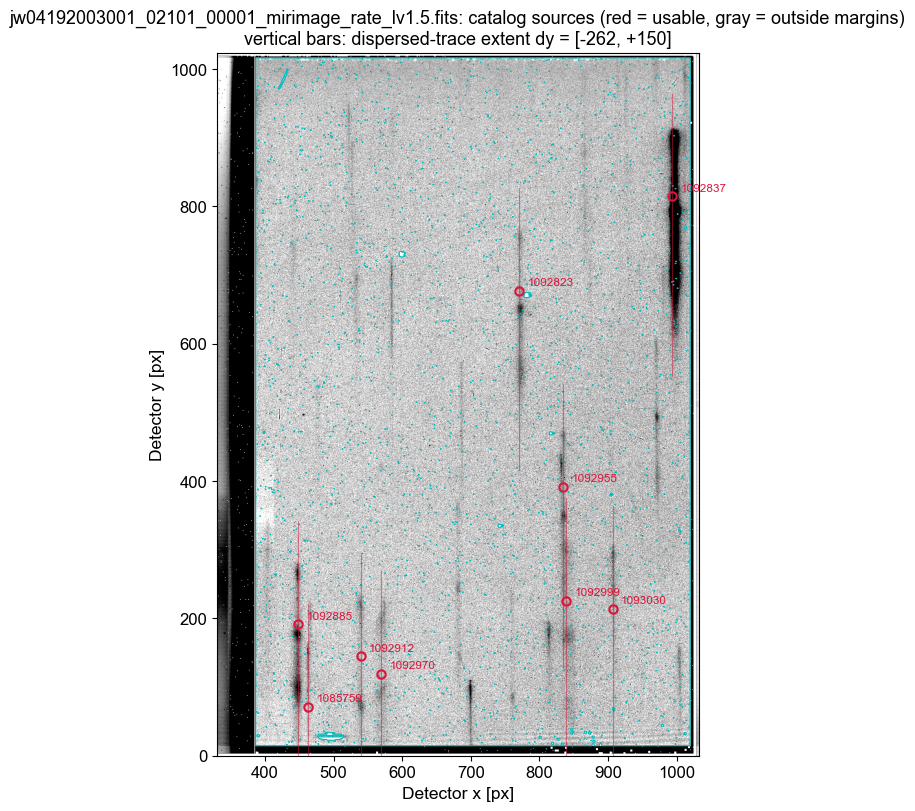

In [8]:
# where the catalog sources sit in the first exposure
E0 = lv15_files[0]
sci15 = fits.getdata(E0, 'SCI')

fig, ax = plt.subplots(figsize = (9.5, 8.0), constrained_layout = True)

v = np.nanpercentile(sci15[in_wfss], [2, 99.5])
ax.imshow(sci15, origin = 'lower', cmap = 'gray_r', vmin = v[0], vmax = v[1])
ax.contour(in_wfss, levels = [0.5], colors = 'c', linewidths = 0.8)

for r in cat:
    cov = covering_exposures(ra = float(r['RA']), dec = float(r['DEC']), files = [E0])
    co = SkyCoord(float(r['RA']), float(r['DEC']), unit = u.deg)
    x, y = (float(q) for q in awcs.utils.skycoord_to_pixel(co, WCS_MAP[E0]))
    color = 'crimson' if cov else 'gray'
    ax.plot(x, y, 'o', ms = 6, mfc = 'none', mec = color, mew = 1.5)
    ax.annotate(str(r['ID']), (x, y), textcoords = 'offset points', xytext = (6, 4),
                fontsize = 8.5, color = color)
    if cov:   # show the trace footprint (dy range; the dx tilt is a few px)
        ax.plot([x, x], [y + DY_MIN, y + DY_MAX], '-', color = 'crimson', lw = 0.8, alpha = 0.5)

ax.set(xlim = (330, 1032), ylim = (0, 1024), xlabel = 'Detector x [px]', ylabel = 'Detector y [px]',
       title = f'{E0.name}: catalog sources (red = usable, gray = outside margins)\n'
             'vertical bars: dispersed-trace extent dy = [-262, +150]')

plt.show()

## Step 6 — Rectify a dispersed trace

Two polynomial tables (the v2.1 trace calibration) define the spectral geometry for a
source at direct-imaging position (x₀, y₀):

* **Trace** `DISP_LRS_WFSS_v2.1.dat` — the cross-dispersion offset dx(x₀, y₀, dy): a cubic polynomial in (x₀−1024, y₀−1024) for each of the three coefficients of a quadratic in dy (30 coefficients; form `fit_disp_order23`). Note that the `-1024` subtraction follows the same functional form that I defined earlier for NIRCam WFSS, although the MIRI FoV and pixel counts are much smaller than those of NIRCam. Tracing accuracy: MAD 0.055 px.
  
* **Wavelength** `DISPL_LRS_WFSS_P750L_v3.1.dat` — the dispersion relation dy(x₀, y₀, λ): a cubic in Δλ = λ − 3.95 µm whose coefficients depend on (x₀, y₀) (16 coefficients; form `fit_disp_order32`). The 3.95 µm reference was also inherited from the NIRCam tooling, although the true undeflected wavelength for MIRI WFSS is about 8.24 µm. We invert it numerically to get λ(dy). Wavelengths are **vacuum**, uncorrected for the spacecraft velocity (please apply the barycentric correction from the `VELOSYS` header if you need <100 km/s absolute accuracy).

`rectify()` builds a (dy × 53 px) cutout that follows the trace with row-wise subpixel shifts (linear interpolation), subtracts a per-row local background estimated from the cutout edges (|Δx| > 11 px), and integrates the inner ±10 px. Three kinds of pixels are masked and tracked (returned as `m2`):

* `DO_NOT_USE | SATURATED` DQ flags;
* unphysical negatives (more than 5σ below zero by their own pipeline error);
* **corrupted-low pixels with no usable DQ flag** — cosmic-ray-shower skirts and badly corrected jumps read 30–100% low on bright traces. On a significantly detected trace (running median of the same cross-dispersion column over ±4 rows above 5σ), pixels more than 4σ *and* 40% below that running median are rejected; real P750L spectral features are broader than the window wherever the trace is bright enough to trigger the test. This matters most for 2-exposure co-adds at near-identical dithers (like JADES-GN-1092837 here): the defects sit at the same detector position in both exposures, so no exposure-to-exposure rejection can see them.

Rows where >max(2, 20%) of the aperture pixels are masked are dropped (their aperture sum would be biased low) — the co-add in step 8 fills masked pixels and dropped rows in from the other exposures, or leaves an honest gap.

GN 1092837 at (x0, y0) = (993.1, 814.6) in jw04192003001_02101_00001_mirimage_rate_lv1.5.fits
rows: 361 with valid wavelengths, 4.00-13.63 um


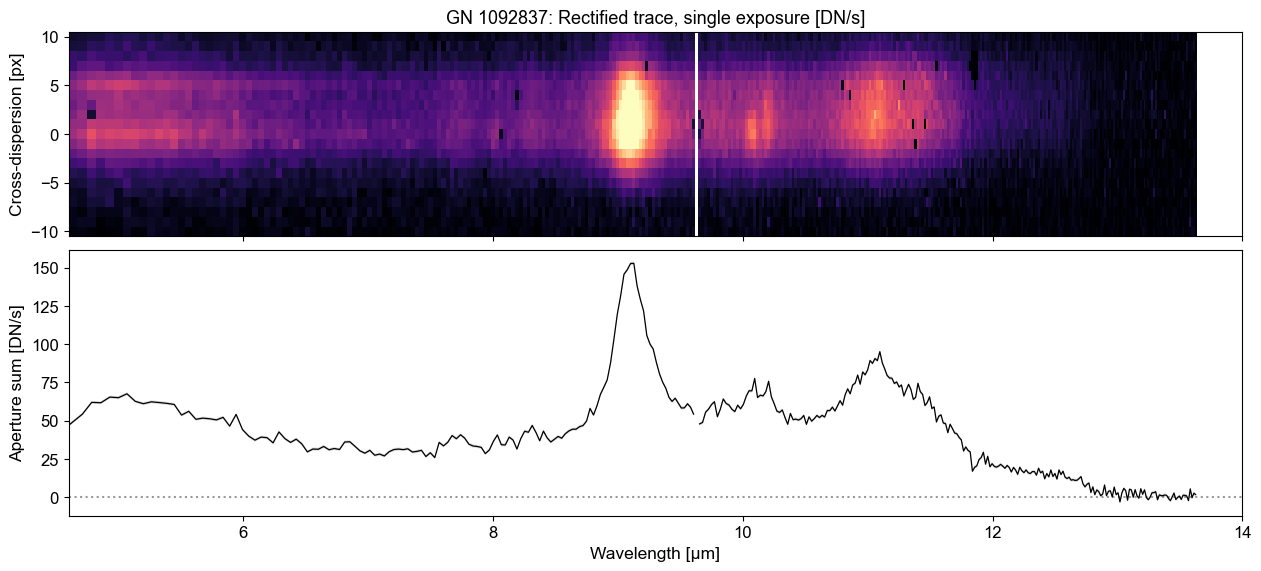

In [9]:
P_DXS = ascii.read(CAL_DIR / 'DISP_LRS_WFSS_v2.1.dat')['col0'].data        # 30 coeffs
P_DYS = ascii.read(CAL_DIR / 'DISPL_LRS_WFSS_P750L_v3.1.dat')['col0'].data  # 16 coeffs


def eval_fit_disp_order23(xpix, ypix, dy, p = None):
    """Trace: dx(x0, y0, dy) = A(x,y) + B(x,y)*dy + C(x,y)*dy^2,
    with A, B, C cubic polynomials of (x0-1024, y0-1024).

    xpix, ypix : direct-image detector position(s) of the source [px]
    dy         : dispersion-direction offset(s) from that position [px]
    p          : the 30 trace coefficients (default: the v2.1 table)
    """
    p = P_DXS if p is None else p
    a, b, c = p[0:10], p[10:20], p[20:30]
    xp, yp = np.asarray(xpix) - 1024.0, np.asarray(ypix) - 1024.0
    dy = np.asarray(dy)

    def cubic(coefs, xp, yp):
        return (coefs[0]
                + coefs[1] * xp + coefs[2] * yp
                + coefs[3] * xp**2 + coefs[4] * xp * yp + coefs[5] * yp**2
                + coefs[6] * xp**3 + coefs[7] * xp**2 * yp + coefs[8] * xp * yp**2 + coefs[9] * yp**3)

    A = cubic(a, xp, yp); B = cubic(b, xp, yp); C = cubic(c, xp, yp)
    return A + B * dy + C * dy**2


def eval_fit_disp_order32(xpix, ypix, lam, p = None):
    """Dispersion: dy(x0, y0, lambda), cubic in dlam = lambda - 3.95 um with
    (x0, y0)-dependent coefficients of decreasing polynomial degree (6+6+3+1).

    xpix, ypix : direct-image detector position(s) of the source [px]
    lam        : wavelength(s) [um]
    p          : the 16 dispersion coefficients (default: the v2.1 table)
    """
    p = P_DYS if p is None else p
    a, b, c, d = p[0:6], p[6:12], p[12:15], p[15:16]
    xp, yp = np.asarray(xpix) - 1024.0, np.asarray(ypix) - 1024.0
    dlam = np.asarray(lam) - 3.95

    def quad(coefs, xp, yp):
        return (coefs[0]
                + coefs[1] * xp + coefs[2] * yp
                + coefs[3] * xp**2 + coefs[4] * xp * yp + coefs[5] * yp**2)

    def lin(coefs, xp, yp):
        return coefs[0] + coefs[1] * xp + coefs[2] * yp

    A = quad(a, xp, yp); B = quad(b, xp, yp); C = lin(c, xp, yp); D = d[0]
    return A + B * dlam + C * dlam**2 + D * dlam**3


def rectify(sci, err, dq, x0, y0, ap_half = AP_HALF):
    """Rectify the dispersed trace of a source at detector position (x0, y0).

    sci, err, dq : SCI / ERR / DQ arrays of one lv1.5 exposure
    x0, y0       : direct-image position of the source [px]
    ap_half      : half width of the extraction window [px]

    Returns (lam1, s1, se, c2, e2, m2):
      lam1 : wavelength per row [um]
      s1   : background-subtracted aperture sum (+-ap_half px) per row [DN/s]
      se   : 1-sigma uncertainty of s1 [DN/s]
      c2   : background-subtracted 2D cutout, aperture columns only [DN/s]
      e2   : per-pixel uncertainties of c2 [DN/s]
      m2   : mask of unusable aperture pixels (DQ-flagged or corrupted-low)
    """
    dy_arr = np.arange(DY_MIN, DY_MAX + 1, 1.0)
    dx_arr = eval_fit_disp_order23(xpix = np.full_like(dy_arr, x0),
                                   ypix = np.full_like(dy_arr, y0), dy = dy_arr)
    y_lo = int(np.clip(y0 + DY_MIN, 4, 1020)); y_hi = int(np.clip(y0 + DY_MAX, 4, 1020))
    ny = y_hi - y_lo
    c2 = np.full((ny, 2 * XHALF + 1), np.nan); e2 = np.full((ny, 2 * XHALF + 1), np.nan)
    m2 = np.zeros((ny, 2 * XHALF + 1), bool)
    for i, yr in enumerate(range(y_lo, y_hi)):
        dy = yr - y0
        xc = x0 + np.interp(dy, dy_arr, dx_arr)
        xlo = int(np.floor(xc)) - XHALF; xhi = xlo + 2 * XHALF + 2
        if xlo < 0 or xhi >= sci.shape[1]:
            continue
        rowv = sci[yr, xlo:xhi].copy(); rowe = err[yr, xlo:xhi].copy()
        # DQ mask + unphysical negatives (>5 sigma below zero by their own error)
        badm = ((dq[yr, xlo:xhi] & (DO_NOT_USE | SATURATED)) > 0) \
            | (rowv < -5.0 * rowe)
        rowv[badm] = np.nan
        f = xc - np.floor(xc)                      # row-wise subpixel shift
        c2[i] = ndimage.shift(np.nan_to_num(rowv, nan = 0.0), -f, order = 1,
                              mode = 'nearest')[:2 * XHALF + 1]
        e2[i] = ndimage.shift(np.nan_to_num(rowe, nan = 9e9), -f, order = 1,
                              mode = 'nearest')[:2 * XHALF + 1]
        m2[i] = ndimage.shift(badm.astype(float), -f, order = 1,
                              mode = 'nearest')[:2 * XHALF + 1] > 0.25
    # corrupted-low pixels that carry no usable DQ flag (cosmic-ray-shower
    # skirts, badly corrected jumps): on a significantly detected trace,
    # reject pixels far below the running median of their cross-dispersion
    # column over +-4 rows in wavelength. Real P750L spectral features are
    # broader than this window wherever the trace is bright enough for the
    # test to trigger. Without this, 2-exposure co-adds at near-identical
    # dithers retain these defects — they sit at the same detector position
    # in both exposures and the pairwise rejection of step 8 (built for
    # positive outliers) cannot see them.
    c2m = np.where(m2, np.nan, c2)
    sh = np.full((8,) + c2.shape, np.nan)
    for k, off in enumerate((-4, -3, -2, -1, 1, 2, 3, 4)):
        if off > 0:
            sh[k, off:] = c2m[:-off]
        else:
            sh[k, :off] = c2m[-off:]
    with np.errstate(invalid = 'ignore'):
        runmed = np.nanmedian(sh, axis = 0)
        low = (runmed > 5.0 * e2) & (c2m < runmed - 4.0 * e2) \
            & (c2m < 0.6 * runmed)
    m2 |= low
    c2[low] = 0.0          # zero-filled like DQ-masked pixels (census below)
    # per-row local background from the cutout edges (outside the aperture)
    edge = np.concatenate([c2[:, :XHALF - ap_half - 1],
                           c2[:, XHALF + ap_half + 2:]], axis = 1)
    c2b = c2 - np.nanmedian(edge, axis = 1)[:, None]
    ap = slice(XHALF - ap_half, XHALF + ap_half + 1)
    s1 = np.nansum(c2b[:, ap], axis = 1)
    se = np.sqrt(np.nansum(e2[:, ap]**2, axis = 1))
    # rows with substantial masked coverage in the aperture are
    # flux-incomplete (masked px sum as 0): drop them — the co-add fills in
    # from exposures where the region is clean, or leaves an honest gap
    nbad = m2[:, ap].sum(axis = 1)
    bad_row = nbad > max(2, int(0.2 * (2 * ap_half + 1)))
    s1[bad_row] = np.nan
    c2b[bad_row, :] = np.nan
    # wavelength per row: numerically invert dy(lambda)
    dy1 = np.arange(y_lo, y_hi) - y0
    lg = np.linspace(4.0, 14.3, 740)
    dyg = eval_fit_disp_order32(xpix = np.full_like(lg, x0),
                                ypix = np.full_like(lg, y0), lam = lg)
    o = np.argsort(dyg)
    lam1 = interpolate.interp1d(dyg[o], lg[o], bounds_error = False,
                                fill_value = np.nan)(dy1)
    return lam1, s1, se, c2b[:, ap], e2[:, ap], m2[:, ap]


# demonstrate on the brightest source in the first covering exposure
gid_demo = 1092837
row = cat[cat['ID'] == gid_demo][0]
E, x0, y0 = cov_map[gid_demo][0]
with fits.open(E) as h:
    sciE = h['SCI'].data.astype(float); errE = h['ERR'].data.astype(float)
    dqE  = h['DQ'].data.astype(np.uint32)
lam1, s1, se, c2, e2, m2 = rectify(sci = sciE, err = errE, dq = dqE,
                                   x0 = x0, y0 = y0, ap_half = AP_HALF)
ok = np.isfinite(lam1)
print(f'GN {gid_demo} at (x0, y0) = ({x0:.1f}, {y0:.1f}) in {E.name}')
print(f'rows: {ok.sum()} with valid wavelengths, '
      f'{lam1[ok].min():.2f}-{lam1[ok].max():.2f} um')

o = np.argsort(lam1[ok])
fig, axes = plt.subplots(2, 1, figsize = (12.5, 5.6), sharex = True,
                         height_ratios = [1, 1.3], constrained_layout = True)
v = np.nanpercentile(c2[ok], [5, 99.5])
axes[0].pcolormesh(lam1[ok][o], np.arange(c2.shape[1]) - AP_HALF, c2[ok][o].T,
                   cmap = 'magma', vmin = v[0], vmax = v[1], shading = 'auto')
axes[0].set(ylabel = 'Cross-dispersion [px]',
            title = f'GN {gid_demo}: Rectified trace, single exposure [DN/s]')
axes[1].plot(lam1[ok][o], s1[ok][o], lw = 0.9, color = 'k')
axes[1].fill_between(lam1[ok][o], (s1 - se)[ok][o], (s1 + se)[ok][o],
                     color = '0.8', alpha = 0.7, lw = 0)
axes[1].axhline(0, color = 'k', ls = ':', alpha = 0.4)
axes[1].set(xlabel = 'Wavelength [µm]', ylabel = 'Aperture sum [DN/s]', xlim = (4.6, 14.0))
plt.show()

### The trace + dispersion model across the field

To see the full spectral geometry at once, the animation below evaluates the two
polynomial tables over a 4 × 4 grid of virtual sources (white stars). As wavelength
increases from 4.8 to 13.8 µm, each dispersed position (dots colored by wavelength;
circled dot = current wavelength) walks down the detector (−y) with the slight
position- and wavelength-dependent x tilt that `rectify()` follows row by row. Sources
in the lower part of the field lose their red end off the detector bottom — the
coverage effect discussed in step 11. The GIF is written to `media/`.

media/wfss_trace_dispersion.gif: 45 frames, 0.4 MB


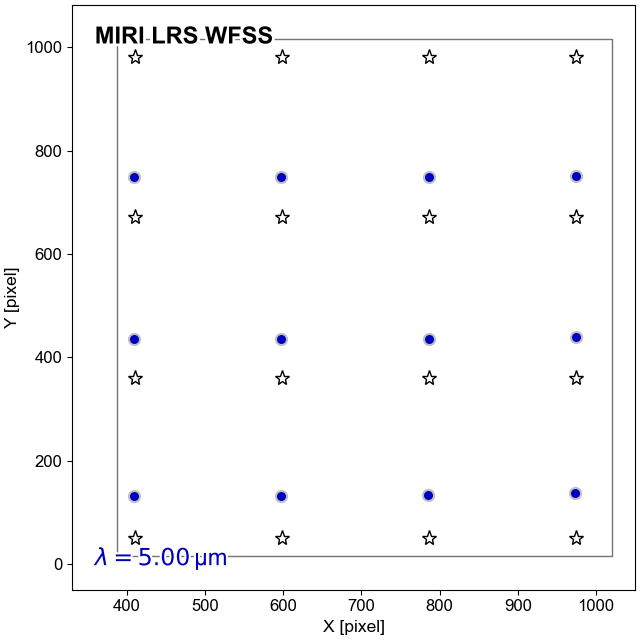

In [10]:
import matplotlib.patheffects as pe
from PIL import Image as PILImage

GIF_PATH = Path('media') / 'wfss_trace_dispersion.gif'
GIF_PATH.parent.mkdir(exist_ok = True)

xs0 = np.linspace(410, 974, 4)            # virtual-source grid in the WFSS region
ys0 = np.linspace(50, 982, 4)
x_mat, y_mat = np.meshgrid(xs0, ys0)
x0s, y0s = x_mat.flatten(), y_mat.flatten()

get_color_w = lambda w: plt.cm.jet((w - 4.5) / (13.5 - 4.5))
frames = []
for w_end in np.arange(5.0, 13.81, 0.2):
    fig, ax = plt.subplots(figsize = (6.4, 6.4))
    ax.plot(x0s, y0s, ls = 'none', marker = '*', color = 'k', mfc = 'w', ms = 11, zorder = 99)
    ax.plot([WFSS_X[0], WFSS_X[1], WFSS_X[1], WFSS_X[0], WFSS_X[0]],
            [WFSS_Y[0], WFSS_Y[0], WFSS_Y[1], WFSS_Y[1], WFSS_Y[0]],
            color = '0.45', lw = 1.0)
    w_arr = np.arange(4.8, w_end + 1e-6, 0.05)
    for tmp_w in w_arr:
        dy = eval_fit_disp_order32(xpix = x0s, ypix = y0s, lam = np.full_like(x0s, tmp_w))
        dx = eval_fit_disp_order23(xpix = x0s, ypix = y0s, dy = dy)
        show = (y0s + dy >= 4) & (y0s + dy <= 1028)
        ax.plot((x0s + dx)[show], (y0s + dy)[show], color = get_color_w(tmp_w),
                marker = '.', ms = 3.5, ls = 'none', mec = 'none')
    show = (y0s + dy >= 4) & (y0s + dy <= 1028)   # current-wavelength markers
    ax.plot((x0s + dx)[show], (y0s + dy)[show], ls = 'none', marker = 'o',
            color = get_color_w(w_arr[-1]), mec = 'silver', ms = 8, mew = 1.5)
    ax.text(0.04, 0.965, 'MIRI LRS WFSS', transform = ax.transAxes, fontsize = 17,
            weight = 'bold', va = 'top',
            path_effects = [pe.withStroke(linewidth = 4, foreground = 'w')])
    ax.text(0.04, 0.03, r'$\lambda = %.2f\,$µm' % w_arr[-1], transform = ax.transAxes,
            fontsize = 17, color = get_color_w(w_arr[-1]), va = 'bottom',
            path_effects = [pe.withStroke(linewidth = 3, foreground = 'w')])
    ax.set(xlabel = 'X [pixel]', ylabel = 'Y [pixel]', xlim = (330, 1050), ylim = (-50, 1082))
    fig.tight_layout(pad = 0.3)
    fig.canvas.draw()
    frames.append(PILImage.fromarray(np.asarray(fig.canvas.buffer_rgba())[..., :3]))
    plt.close(fig)

frames[0].save(GIF_PATH, save_all = True, append_images = frames[1:],
               duration = [120] * (len(frames) - 1) + [900], loop = 0)
print(f'{GIF_PATH}: {len(frames)} frames, {GIF_PATH.stat().st_size / 1e6:.1f} MB')
from IPython.display import Image as IPyImage
IPyImage(filename = str(GIF_PATH))

## Step 7 — Flux calibration with fR(λ)

The response table `FLUXCAL_LRS_WFSS_v3.1.dat` gives fR(λ) in **(aperture-summed DN/s) per Jy**: dividing the per-row aperture sum by fR(λ) yields the source flux density in Jy (×10³ → mJy). Provenance per wavelength bin (`anchor` column):

* `anchor = 1` (7.44–13.81 µm) — measured **directly** on the CALSPEC standard HD 163466 (CAL-9265, 5-position slitless grid); σ(fR)/fR ≈ 0.3% per bin, absolute accuracy 1–2% (CALSPEC-limited).
  
* `anchor = 0` (4.46–7.44 µm) — the GOODS-N G/K stellar-ensemble *shape* (the standard saturates blueward of 7.44 µm), rescaled to the CALSPEC overlap; ~5% shape accuracy.

The response fR was derived from calibrator stars extracted with the same procedure as the science spectra in this notebook, only with a wider cross-dispersion window (±20 px instead of ±10 px). Two measured aperture facts are worth knowing: the ±10 px window used here captures 97.2–97.4% of the ±20 px flux, so point-source fluxes come out low by ≲3% relative to the response definition; and the light missing from the ±20 px calibration window itself is absorbed into fR by construction, so calibrated point-source fluxes are **total** fluxes.

The flux scale has been verified end-to-end on data not used in the calibration fits:

* **Field star** — for a Gaia G = 17.1 mag star whose mid-infrared SED is predicted from 2MASS and WISE photometry alone (no JWST data involved), observed/expected = 1.016 ± 0.042.
* **LMC planetary nebula** — synthetic F560W photometry of its calibrated spectrum agrees to 1.01 with aperture photometry on the direct F560W verification image of the same visit, after correcting the image photometry for its aperture losses (STPSF encircled energies; the strong 5.6 µm PSF wings and cruciform are non-negligible) — within the 1–2% CALSPEC-tied absolute scale.


**A note on the L-flat** (the low-spatial-frequency position dependence of the response across the field): we tested it and found it to be **consistent with identity**, so this pipeline applies no L-flat correction and the reference data release ships no L-flat file. The evidence: (1) the CALSPEC standard HD 163466, measured on a 5-position grid across the WFSS region, gives max |L − 1| = 0.010 (MAD 0.008); (2) repeated spectra of the same GOODS-N/GOODS-S stars and galaxies observed at different detector positions and epochs agree to MAD 4.4%. Both of these numbers are below the flux-calibration error budget at the corresponding wavelengths.

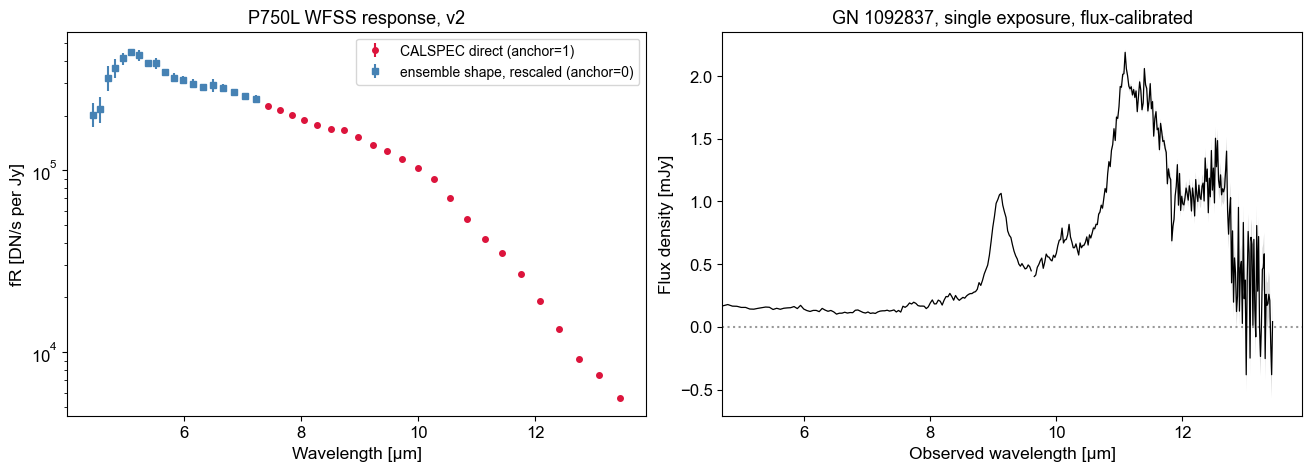

In [11]:
tR = ascii.read(CAL_DIR / 'FLUXCAL_LRS_WFSS_v3.1.dat')
R_WAVE = np.asarray(tR['wavelength'], float)
R_VAL  = np.asarray(tR['DN/s/pixel/Jy'], float)


def fR(l):
    """Response fR(lambda): aperture-summed DN/s per Jy of source flux density.

    l : wavelength(s) [um]; NaN outside the calibrated 4.46-13.81 um range
    """
    return np.interp(l, R_WAVE, R_VAL, left = np.nan, right = np.nan)


fig, axes = plt.subplots(1, 2, figsize = (13.0, 4.6), constrained_layout = True)
anch = np.asarray(tR['anchor'], int) == 1
axes[0].errorbar(R_WAVE[anch], R_VAL[anch], yerr = np.asarray(tR['err'])[anch],
                 fmt = 'o', ms = 4, color = 'crimson', label = 'CALSPEC direct (anchor=1)')
axes[0].errorbar(R_WAVE[~anch], R_VAL[~anch], yerr = np.asarray(tR['err'])[~anch],
                 fmt = 's', ms = 4, color = 'steelblue', label = 'ensemble shape, rescaled (anchor=0)')
axes[0].set(xlabel = 'Wavelength [µm]', ylabel = 'fR [DN/s per Jy]', yscale = 'log',
            title = 'P750L WFSS response, v2')
axes[0].legend()

# flux-calibrate the single-exposure spectrum from step 6
ls = lam1[ok][o]
R  = fR(ls)
f1_mJy = s1[ok][o] / R * 1e3
e1_mJy = se[ok][o] / R * 1e3
axes[1].plot(ls, f1_mJy, lw = 0.9, color = 'k')
axes[1].fill_between(ls, f1_mJy - e1_mJy, f1_mJy + e1_mJy, color = '0.8', alpha = 0.7, lw = 0)
axes[1].axhline(0, color = 'k', ls = ':', alpha = 0.4)
axes[1].set(xlabel = 'Observed wavelength [µm]', ylabel = 'Flux density [mJy]',
            xlim = (4.7, 13.9), title = f'GN {gid_demo}, single exposure, flux-calibrated')
plt.show()

## Step 8 — Co-add exposures

`coadd_source()` repeats steps 6+7 for every covering exposure and combines them:

1. **Cross-dispersion recentering** (two-pass): the catalog position can sit 0.3–4 px
   off the observed trace (catalog/WCS offsets); we measure the continuum centroid
   (5.5–11 µm) of the first-pass cutout and re-rectify at the corrected x₀. Switch it
   off manually with `recenter = False` (the `RECENTER` flag below) to extract exactly
   at the catalog/WCS position — useful when a brighter neighbour inside the cutout
   could hijack the centroid, or when you trust your astrometry more than the
   low-S/N continuum.
2. **Common grid**: each exposure's 1D and 2D spectra are interpolated onto a 0.01 µm
   grid (4.6–13.8 µm). Grid points are masked where the bracketing native samples are
   more than 3× the local median row spacing apart (≥2 dropped rows) — an adaptive
   criterion, because the native spacing itself runs from ~0.02 µm per row in the red
   to ~0.11 µm per row at the blue end where the prism dispersion is lowest. (A fixed
   gap threshold would amputate everything blueward of ≈5.1 µm.)
3. **PA grouping**: the cross-dispersion axis of the 2D co-add must have a single sky
   orientation, so only the dominant dispersion-PA group (±10°) is stacked. Here both
   epochs disperse at PA ≈ 320–323° → one group of 8; if the PAs were fragmented, the
   largest 10° bin would win. For **compact sources** the orientation carries little
   information, so you can switch the grouping off manually with `pa_group = False`
   (the `PA_GROUP` flag below) and stack all covering exposures regardless of PA: the
   1D spectrum gains depth and is otherwise unaffected; only the sky orientation of
   the 2D cross-dispersion axis becomes mixed (and the returned `pa_disp`/`pa_x` are
   then medians over heterogeneous angles).
4. **Inverse-variance weighted mean with sigma clipping**: pixels deviating by
   >2 × MAD-RMS (the threshold for <10 exposures; 3 × for ≥10) from the per-pixel median
   are rejected, unless that would leave <2 surviving exposures.
   **N = 2 special case**: MAD clipping is meaningless between two exposures; instead,
   where the pair disagrees by >4 × the propagated pair noise, the **higher** pixel is
   rejected (cosmic rays and hot pixels are positive). Low-side defects need no
   pairwise test — they are masked per exposure in `rectify()` (step 6), which is the
   only place they *can* be caught when they correlate between near-identically-
   dithered exposures.

  JADES-GN-1092912: 8 exposures in the PA group (0 dropped), dispersion PA = 321.4 deg
  JADES-GN-1092837: 2 exposures in the PA group (0 dropped), dispersion PA = 320.4 deg


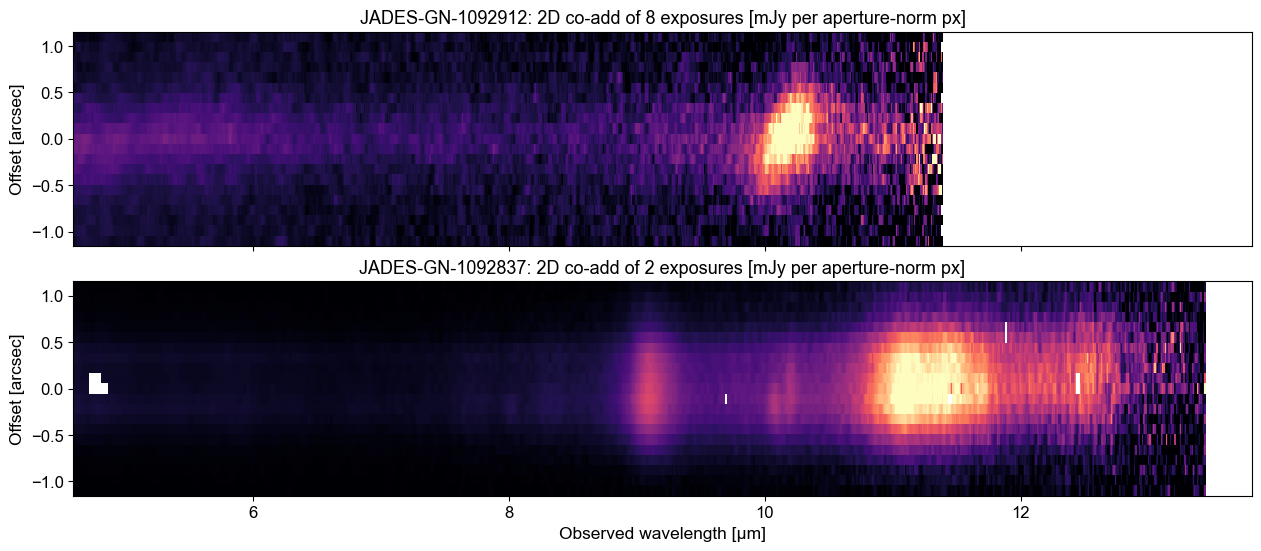

In [12]:
def clipped_coadd(stack, wht, kclip):
    """Sigma-clipped inverse-variance-weighted mean along axis 0.

    stack, wht : (nexp, ...) arrays (NaN = no data)
    kclip      : clip threshold in units of the per-pixel MAD-RMS
    """
    if len(stack) == 2:
        # MAD clipping is meaningless between two exposures; instead reject
        # the HIGHER pixel of a pair that disagrees by >4x the propagated
        # pair noise (cosmic rays / hot pixels are positive)
        with np.errstate(all = 'ignore'):
            sig_pair = np.sqrt(1.0 / wht[0] + 1.0 / wht[1])
            diff = stack[0] - stack[1]
        bad = np.zeros(stack.shape, bool)
        bad[0] = diff > 4.0 * sig_pair
        bad[1] = diff < -4.0 * sig_pair
        w = np.where(bad, np.nan, wht)
        co = np.nansum(np.where(bad, np.nan, stack) * w, axis = 0) / np.nansum(w, axis = 0)
        return co, w
    med = np.nanmedian(stack, axis = 0)
    sig = 1.4826 * np.nanmedian(np.abs(stack - med[None]), axis = 0)
    sig = np.maximum(sig, 1e-12)
    bad = np.abs(stack - med[None]) > kclip * sig[None]
    nsurv = np.sum(np.isfinite(stack) & ~bad, axis = 0)
    bad[:, nsurv < 2] = False         # keep everything where clipping leaves <2 exp
    w = np.where(bad, np.nan, wht)
    co = np.nansum(np.where(bad, np.nan, stack) * w, axis = 0) / np.nansum(w, axis = 0)
    return co, w


def coadd_source(name, ra, dec, exps, ap_half = AP_HALF, recenter = True,
                 pa_group = True, verbose = False):
    """Rectify + flux-calibrate a source in every covering exposure and co-add.

    name     : label used in printed messages
    ra, dec  : source coordinates [deg]
    exps     : list of lv1.5 paths (or (path, x, y) tuples from covering_exposures)
    ap_half  : cross-dispersion half width passed to rectify() [px]
    verbose  : print the PA-group summary
    recenter : two-pass cross-dispersion recentering on the continuum centroid;
               set False to extract exactly at the catalog/WCS position
    pa_group : keep only the dominant dispersion-PA group (+-10 deg); set False
               to stack ALL covering exposures regardless of PA (fine for
               compact sources — only the sky orientation of the 2D
               cross-dispersion axis becomes mixed)
    Returns dict(name, n, n_drop_pa, wave, f1, e1, f2, e2, pa_disp, pa_x) or None.
    """
    co = SkyCoord(ra, dec, unit = u.deg)
    ones, twos, wht1, wvar2 = [], [], [], []
    pad, pax = [], []
    for item in exps:
        E = item[0] if isinstance(item, tuple) else item
        try:
            with fits.open(E) as h:
                sci = h['SCI'].data.astype(float); err = h['ERR'].data.astype(float)
                dq = h['DQ'].data.astype(np.uint32)
            w = WCS_MAP[E]
            x0, y0 = (float(v) for v in awcs.utils.skycoord_to_pixel(co, w))
        except Exception:
            continue
        if not (WFSS_X[0] + MARGIN_X < x0 < WFSS_X[1] - MARGIN_X and
                WFSS_Y[0] + MARGIN_Y < y0 < WFSS_Y[1] - MARGIN_Y):
            continue
        lam1, s1, se, c2, e2, m2 = rectify(sci = sci, err = err, dq = dq,
                                           x0 = x0, y0 = y0, ap_half = ap_half)
        # two-pass cross-dispersion recenter (continuum centroid, 5.5-11 um)
        m_c = np.isfinite(lam1) & (lam1 > 5.5) & (lam1 < 11.0)
        if recenter and m_c.sum() > 40:
            prof = np.nanmedian(c2[m_c], axis = 0)
            prof = np.clip(prof - np.nanmedian(prof), 0, None)
            xs_p = np.arange(len(prof)) - (len(prof) // 2)
            if np.nansum(prof) > 0:
                dxc = float(np.nansum(prof * xs_p) / np.nansum(prof))
                if 0.3 < abs(dxc) <= 4.0:
                    lam1, s1, se, c2, e2, m2 = rectify(sci = sci, err = err, dq = dq,
                                                       x0 = x0 + dxc, y0 = y0,
                                                       ap_half = ap_half)
        ok = np.isfinite(lam1) & np.isfinite(s1) & (se > 0)
        if ok.sum() < 60:
            continue
        # sky position angles of the dispersion (det -y) and cross-disp (det +x)
        c0 = awcs.utils.pixel_to_skycoord(x0, y0, w)
        cD = awcs.utils.pixel_to_skycoord(x0, y0 - 40.0, w)
        cX = awcs.utils.pixel_to_skycoord(x0 + 40.0, y0, w)
        pad.append(c0.position_angle(cD).to_value(u.deg))
        pax.append(c0.position_angle(cX).to_value(u.deg))

        o = np.argsort(lam1[ok]); ls = lam1[ok][o]
        R = fR(ls)
        f1 = (s1[ok][o] / R) * 1e3            # mJy
        e1 = (se[ok][o] / R) * 1e3
        g1 = np.interp(WGRID, ls, f1, left = np.nan, right = np.nan)
        ge = np.interp(WGRID, ls, e1, left = np.nan, right = np.nan)
        cover = np.zeros_like(WGRID, bool)    # no interpolation across gaps
        idx = np.searchsorted(ls, WGRID)
        inb = (idx > 0) & (idx < len(ls))
        # native per-row spacing runs from ~0.02 um (red) to ~0.11 um at the
        # blue end where the prism dispersion is lowest — a fixed gap
        # threshold would amputate everything blueward of ~5.1 um, so flag a
        # gap only where the spacing exceeds 3x its local (+-5-row) median,
        # i.e. where >= 2 consecutive rows were dropped
        dls = np.diff(ls)
        med_dls = np.array([np.median(dls[max(0, j - 5):j + 6])
                            for j in range(len(dls))])
        cover[inb] = (ls[idx[inb]] - ls[idx[inb] - 1]) < 3.0 * med_dls[idx[inb] - 1]
        g1[~cover] = np.nan; ge[~cover] = np.nan
        ones.append(g1); wht1.append(1.0 / ge**2)
        # 2D: flux-calibrate per row, resample each cross-dispersion column.
        # Masked pixels (DQ / corrupted-low) become NaN with NaN weight, so
        # the co-add genuinely fills them from the other exposures.
        c2cal = c2[ok][o] / R[:, None] * 1e3
        e2cal = e2[ok][o] / R[:, None] * 1e3
        mm = m2[ok][o]
        c2cal[mm] = np.nan
        e2cal[mm] = np.nan
        g2 = np.full((len(WGRID), c2cal.shape[1]), np.nan)
        v2 = np.full_like(g2, np.nan)
        for j in range(c2cal.shape[1]):
            g2[:, j] = np.interp(WGRID, ls, c2cal[:, j], left = np.nan, right = np.nan)
            v2[:, j] = np.interp(WGRID, ls, e2cal[:, j], left = np.nan, right = np.nan)
        g2[~cover, :] = np.nan; v2[~cover, :] = np.nan
        twos.append(g2); wvar2.append(1.0 / v2**2)

    if len(ones) < 2:
        return None
    # keep the dominant dispersion-PA group (+-10 deg), unless switched off
    pad = np.array(pad); pax = np.array(pax)
    if pa_group:
        ref = np.median(pad)
        dpa = (pad - ref + 180) % 360 - 180
        keep = np.abs(dpa) < 10.0
        if keep.sum() < max(2, 0.5 * len(pad)):   # fragmented PAs: keep largest bin
            bins = np.arange(0, 361, 10)
            hist, _ = np.histogram(pad % 360, bins = bins)
            b0 = bins[np.argmax(hist)]
            keep = ((pad % 360) >= b0) & ((pad % 360) < b0 + 10)
    else:
        keep = np.ones(len(pad), bool)            # stack all PAs (compact sources)
    n_drop = int((~keep).sum())
    ones  = [x for x, k in zip(ones, keep) if k]
    wht1  = [x for x, k in zip(wht1, keep) if k]
    twos  = [x for x, k in zip(twos, keep) if k]
    wvar2 = [x for x, k in zip(wvar2, keep) if k]
    pa_d = float(np.median(pad[keep])); pa_x = float(np.median(pax[keep]))
    nexp = len(ones)
    if nexp < 2:
        return None
    if verbose:
        print(f'  {name}: {nexp} exposures in the PA group ({n_drop} dropped), '
              f'dispersion PA = {pa_d:.1f} deg')

    kclip = 2.0 if nexp < 10 else 3.0
    ones = np.array(ones); wht1 = np.array(wht1)
    co1, w1c = clipped_coadd(stack = ones, wht = wht1, kclip = kclip)
    ce1 = 1.0 / np.sqrt(np.nansum(w1c, axis = 0))
    twos = np.array(twos); wvar2 = np.array(wvar2)
    co2, w2c = clipped_coadd(stack = twos, wht = wvar2, kclip = kclip)
    ce2 = 1.0 / np.sqrt(np.nansum(w2c, axis = 0))
    return dict(name = name, n = nexp, n_drop_pa = n_drop, wave = WGRID,
                f1 = co1, e1 = ce1, f2 = co2, e2 = ce2, pa_disp = pa_d, pa_x = pa_x)


# manual switches (also used by the full catalog loop in step 10):
RECENTER = True    # False: extract exactly at the catalog/WCS position
PA_GROUP = True    # False: stack all PAs (fine for compact sources)

# co-add the 8-exposure source GN 1092912 and the 2-exposure source GN 1092837
res_demo = {}
for gid in (1092912, 1092837):
    r = cat[cat['ID'] == gid][0]
    res_demo[gid] = coadd_source(name = f'JADES-GN-{gid}', ra = float(r['RA']),
                                 dec = float(r['DEC']), exps = cov_map[gid],
                                 recenter = RECENTER, pa_group = PA_GROUP,
                                 verbose = True)

fig, axes = plt.subplots(2, 1, figsize = (12.5, 5.4), sharex = True, constrained_layout = True)
for ax, gid in zip(axes, (1092912, 1092837)):
    res = res_demo[gid]
    v = np.nanpercentile(res['f2'], [5, 99.2])
    yy = (np.arange(res['f2'].shape[1]) - AP_HALF) * PIX_MIRI
    ax.pcolormesh(res['wave'], yy, res['f2'].T, cmap = 'magma',
                  vmin = v[0], vmax = v[1], shading = 'auto')
    ax.set(ylabel = 'Offset [arcsec]',
           title = f"JADES-GN-{gid}: 2D co-add of {res['n']} exposures [mJy per aperture-norm px]")
axes[1].set_xlabel('Observed wavelength [µm]')
plt.show()

## Step 9 — Extract the 1D spectrum

Two extractions from the 2D co-add, both returned by `extract_1d()`:

* **Boxcar with aperture-loss correction**: the sum of the central ±`box_half` px
  (default 3 px = ±0.33″; change it with the `BOX_HALF` flag below) is divided by
  the fraction of the cross-dispersion profile P that falls inside that window — the aperture-loss correction back to the full ±10 px normalization that
  fR(λ) is tied to, so both extraction methods share the same flux scale. The factor
  is returned by `extract_1d()` (and printed below); it is ~1.2 for compact sources
  and grows with source extent.
* **Optimal ([Horne 1986](https://ui.adsabs.harvard.edu/abs/1986PASP...98..609H))**:
  per row, fit the amplitude of P by inverse-variance weighting,
  f = Σ P D w / Σ P² w — maximizes S/N for the adopted profile. Rows constrained by
  <5 valid cross-dispersion pixels are dropped (their amplitudes are error-dominated
  spikes). Before either extraction, P is shift-aligned to the observed continuum
  centroid of the 2D co-add (0.2–4 px tolerance). This alignment can be switched off
  manually with `align = False` (the `ALIGN_PROFILE` flag below) — recommended for
  faint sources whose extraction window contains a brighter neighbour: the centroid
  (and the extraction with it) could otherwise walk onto the contaminant, replacing
  the faint source's SED with the neighbour's.

**The cross-dispersion profile P matters**: both the Horne flux scale and the boxcar
aperture correction are set by P, and many mid-IR-bright galaxies are clearly resolved —
a too-narrow profile silently underestimates the flux by tens of per cent.
Three options, in the order you should try them:

1. **Measured profile (default)** — `profile_from_coadd()` collapses the 2D co-add
   continuum itself (median over 5.5–11 µm) into a noise-guarded, non-negative,
   normalized profile. For anything with detectable continuum this captures the true
   source extent with no external data.
2. **Gaussian fallback** — `gaussian_profile()` (σ = 0.25″, FWHM ≈ 0.6″ ≈ the 5–8 µm
   PSF convolved with a compact galaxy); used automatically when the measured profile
   is too noisy (integrated profile S/N < 10) **or not centered on the target**
   (|centroid| > 3 px — usually a brighter contaminating trace inside the window;
   the centered Gaussian then keeps the extraction on the target, but inspect the
   2D co-add).
3. **Imaging-based profile (hook)** — any non-negative 21-element array with Σ P = 1
   can be passed to `extract_1d()`. The Sun (2026) atlas collapses a NIRCam/F444W
   cutout along the dispersion direction, after rotating it to the spectrum's sky
   orientation (`pa_disp`/`pa_x` in the co-add dict) and resampling to the 21 × 0.11″
   grid — best for sources too faint to define their own profile but resolved in
   imaging.

`extract_1d()` returns both extractions and reports their median continuum S/N; the
catalog loop in step 10 adopts the optimal extraction unless the boxcar S/N is
decisively (>5%) higher, so that statistical near-ties cannot flip the adopted flux.
If the two extractions disagree systematically for a source, treat that as a warning
sign — usually a mismatched or wing-contaminated profile in a crowded field (compare
`flux_mJy` and `flux_alt_mJy` in the output tables).

JADES-GN-1092912: profile = measured; median continuum S/N — optimal 9.4, boxcar 8.6
boxcar aperture-loss correction: 1 / P(±3 px) = 1.33


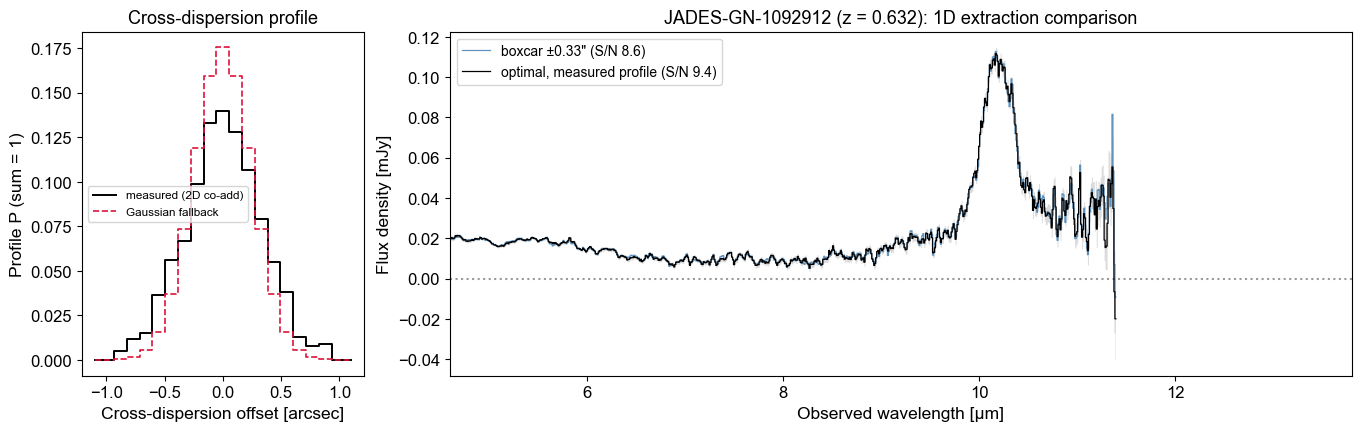

In [13]:
def gaussian_profile(sigma_arcsec = 0.25, ap_half = AP_HALF):
    """Fallback cross-dispersion profile: Gaussian on the (2*ap_half+1)-px grid.

    sigma_arcsec : Gaussian sigma of the profile [arcsec]
    ap_half      : half width of the profile grid [px]
    """
    y = (np.arange(2 * ap_half + 1) - ap_half) * PIX_MIRI
    P = np.exp(-0.5 * (y / sigma_arcsec)**2)
    return P / P.sum()


def profile_from_coadd(res, snr_min = 10.0):
    """Default cross-dispersion profile: measured from the 2D co-add continuum.

    Median-collapses the 5.5-11 um rows of the co-added 2D spectrum, clips
    negatives, and normalizes. If the integrated profile S/N is below snr_min
    (continuum too faint to define its own profile), returns the Gaussian
    fallback instead. Returns (P, label).

    res     : co-add dict from coadd_source() (uses f2, e2, wave)
    snr_min : minimum integrated profile S/N to accept the measured profile
    """
    D, E = res['f2'], res['e2']
    m = np.isfinite(res['wave']) & (res['wave'] > 5.5) & (res['wave'] < 11.0)
    with np.errstate(all = 'ignore'):
        prof = np.nanmedian(np.where(np.isfinite(D[m]), D[m], np.nan), axis = 0)
        nrow = np.sum(np.isfinite(D[m]), axis = 0)
        # uncertainty of a median of nrow values ~ 1.253 * sigma / sqrt(nrow)
        eprof = 1.253 * np.nanmedian(np.where(np.isfinite(E[m]), E[m], np.nan),
                                     axis = 0) / np.sqrt(np.maximum(nrow, 1))
    Ppos = np.clip(np.nan_to_num(prof, nan = 0.0), 0, None)
    snr_int = np.nansum(Ppos) / np.sqrt(np.nansum(eprof**2))
    if not (np.isfinite(snr_int) and snr_int >= snr_min and Ppos.sum() > 0):
        return gaussian_profile(), 'gaussian(faint)'
    xs = np.arange(len(Ppos)) - AP_HALF
    cen = float(np.sum(Ppos * xs) / Ppos.sum())
    if abs(cen) > 3.0:
        # the collapsed light is not centered on the target — usually a brighter
        # contaminating trace inside the window (inspect the 2D!); a centered
        # Gaussian keeps the extraction on the target instead
        return gaussian_profile(), 'gaussian(off-center light)'
    return Ppos / Ppos.sum(), 'measured'


def extract_1d(res, P, align = True, box_half = 3):
    """Boxcar + optimal (Horne) 1D extraction from a 2D co-add dict.

    res   : co-add dict from coadd_source() (uses f2, e2, wave).
    P     : cross-dispersion profile, shape (2*AP_HALF+1,), sum = 1.
            Replace with an image-collapsed profile for resolved sources (see text).
    align : shift P onto the observed continuum centroid of the 2D co-add
            (0.2-4 px tolerance) before extracting. Switch off for faint sources
            whose window contains a brighter neighbour — the centroid (and the
            extraction with it) could otherwise walk onto the contaminant.
    box_half : half width of the boxcar extraction window [px]
            (default 3 px = +-0.33"; any integer < AP_HALF works).
    Returns (f_opt, e_opt, f_box, e_box, snr_opt, snr_box, apc_box), where
    apc_box is the boxcar aperture-loss correction factor 1 / P(+-box_half px).
    """
    D, E = res['f2'], res['e2']
    # align the profile with the observed trace: the 2D continuum centroid can
    # sit ~1-2 px off the catalog position, which would cost Horne S/N
    m = np.isfinite(res['wave']) & (res['wave'] > 5.5) & (res['wave'] < 11.0)
    prof2d = np.nanmedian(np.where(np.isfinite(D[m]), D[m], np.nan), axis = 0)
    prof2d = np.clip(prof2d - np.nanmedian(prof2d), 0, None)
    xs = np.arange(len(prof2d)) - AP_HALF
    if align and np.nansum(prof2d) > 0:
        dc = float(np.nansum(prof2d * xs) / np.nansum(prof2d))
        if 0.2 < abs(dc) <= 4.0:
            P = ndimage.shift(P, dc, order = 1, mode = 'nearest')
            P = np.clip(P, 0, None)
            P = P / max(P.sum(), 1e-9)
    with np.errstate(all = 'ignore'):
        w = 1.0 / E**2
        valid = np.isfinite(D) & np.isfinite(w) & (w > 0)
        num = np.nansum(np.where(valid, P[None, :] * D * w, 0.0), axis = 1)
        den = np.nansum(np.where(valid, P[None, :]**2 * w, 0.0), axis = 1)
        fopt = num / den
        eopt = 1.0 / np.sqrt(den)
        nv = valid.sum(axis = 1)        # drop rows constrained by <5 valid pixels
        fopt[nv < 5] = np.nan
        eopt[nv < 5] = np.nan
    # small-aperture boxcar (+-box_half px) with profile aperture-loss correction
    sl = slice(AP_HALF - box_half, AP_HALF + box_half + 1)
    apc = 1.0 / max(P[sl].sum(), 1e-3)
    fbox = np.nansum(D[:, sl], axis = 1) * apc
    ebox = np.sqrt(np.nansum(E[:, sl]**2, axis = 1)) * apc
    fbox[np.all(~np.isfinite(D[:, sl]), axis = 1)] = np.nan
    snr_o = np.nanmedian(fopt / eopt)
    snr_b = np.nanmedian(fbox / ebox)
    return fopt, eopt, fbox, ebox, snr_o, snr_b, apc


ALIGN_PROFILE = True   # False: keep P centred on the catalog position (faint sources
                       # whose centroid could be pulled by a brighter neighbour)
BOX_HALF = 3           # boxcar half width [px]; 3 px = ±0.33″ (also used in step 10)

res = res_demo[1092912]
P0, plab = profile_from_coadd(res)
fopt, eopt, fbox, ebox, snr_o, snr_b, apc = extract_1d(res = res, P = P0,
                                                       align = ALIGN_PROFILE,
                                                       box_half = BOX_HALF)
print(f'JADES-GN-1092912: profile = {plab}; '
      f'median continuum S/N — optimal {snr_o:.1f}, boxcar {snr_b:.1f}')
print(f'boxcar aperture-loss correction: 1 / P(±{BOX_HALF} px) = {apc:.2f}')

fig, axes = plt.subplots(1, 2, figsize = (13.5, 4.2), width_ratios = [1, 3.2],
                         constrained_layout = True)
yy = (np.arange(2 * AP_HALF + 1) - AP_HALF) * PIX_MIRI
axes[0].step(yy, P0, where = 'mid', color = 'k', lw = 1.4, label = 'measured (2D co-add)')
axes[0].step(yy, gaussian_profile(), where = 'mid', color = 'crimson', lw = 1.2, ls = '--',
             label = 'Gaussian fallback')
axes[0].set(xlabel = 'Cross-dispersion offset [arcsec]', ylabel = 'Profile P (sum = 1)',
            title = 'Cross-dispersion profile')
axes[0].legend(fontsize = 8.5)

axes[1].plot(res['wave'], fbox, lw = 0.9, color = 'steelblue', alpha = 0.85,
             drawstyle = 'steps-mid', label = f'boxcar ±{BOX_HALF * PIX_MIRI:.2f}" (S/N {snr_b:.1f})')
axes[1].plot(res['wave'], fopt, lw = 0.9, color = 'k', drawstyle = 'steps-mid',
             label = f'optimal, measured profile (S/N {snr_o:.1f})')
axes[1].fill_between(res['wave'], fopt - eopt, fopt + eopt, color = '0.8', alpha = 0.7,
                     lw = 0, step = 'mid')
axes[1].axhline(0, color = 'k', ls = ':', alpha = 0.4)
axes[1].set(xlabel = 'Observed wavelength [µm]', ylabel = 'Flux density [mJy]',
            xlim = (4.6, 13.8), title = 'JADES-GN-1092912 (z = 0.632): 1D extraction comparison')
axes[1].legend(loc = 'upper left')
plt.show()

## Step 10 — Extracting Spectra and making figures for the whole catalog

Putting it all together — the per-source work is wrapped in `extract_one()`. `FIXED_POSITION_IDS` lists sources whose extraction must stay pinned to the catalog position (recentering and profile alignment disabled). The loop runs serially by default; the commented `Pool` lines show the parallel variant (`n_proc` from step 4) for bulk extraction of large catalogs, in which case the figures are only written to `products/`, not displayed inline (same platform note as step 4). For every catalog source, co-add (step 8), extract (step 9,
adopting the higher-S/N method), plot the 2D + 1D spectrum with the common mid-IR
line/feature markers at the literature redshift, and save a machine-readable `.ecsv`
(wavelength, adopted flux + error, alternative flux + error; source metadata in
`meta`) plus a `.png` into `products/`.

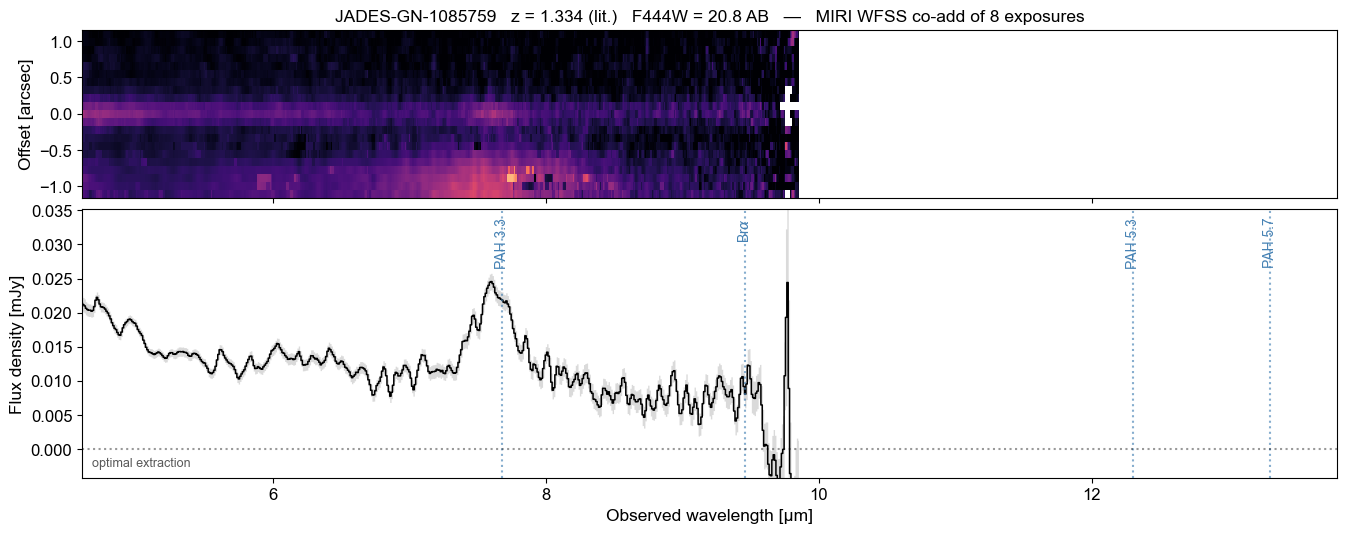

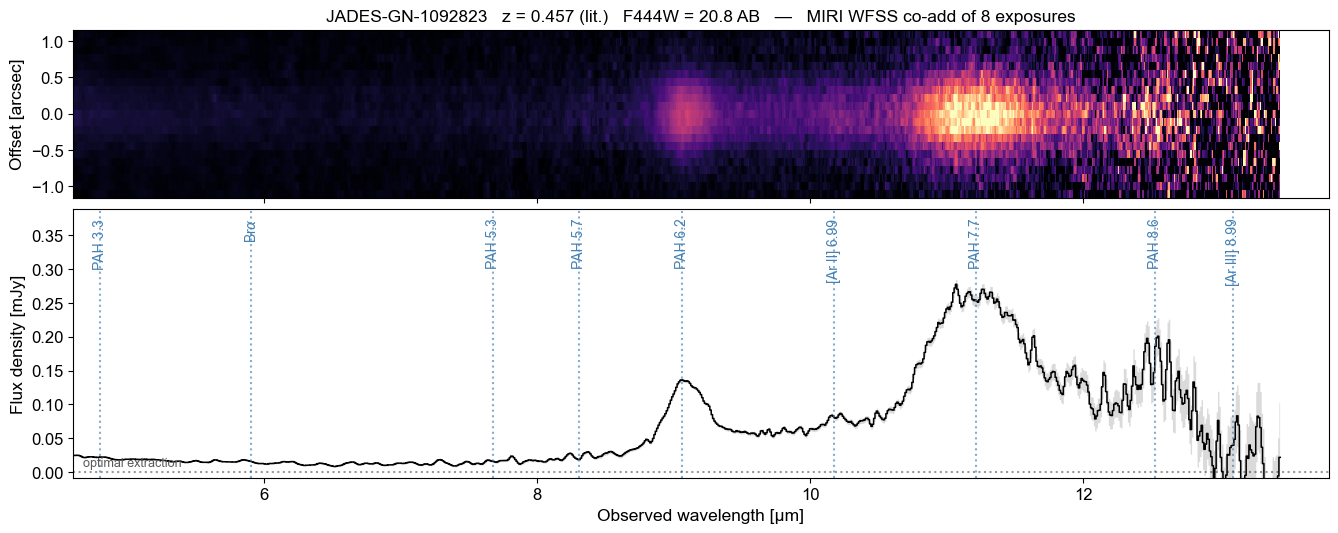

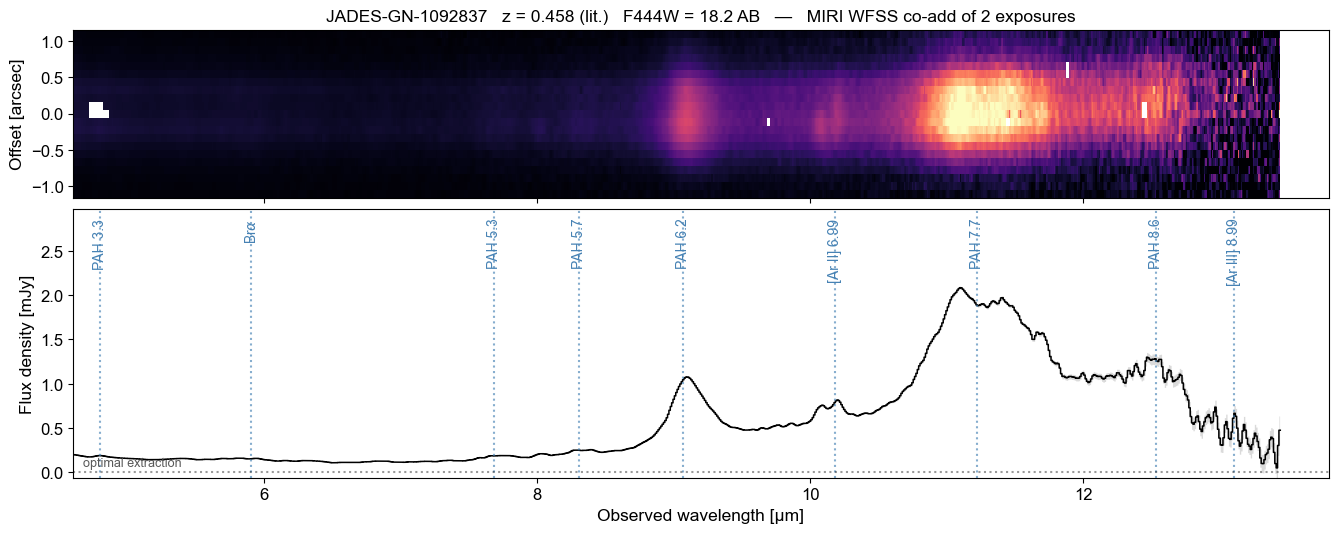

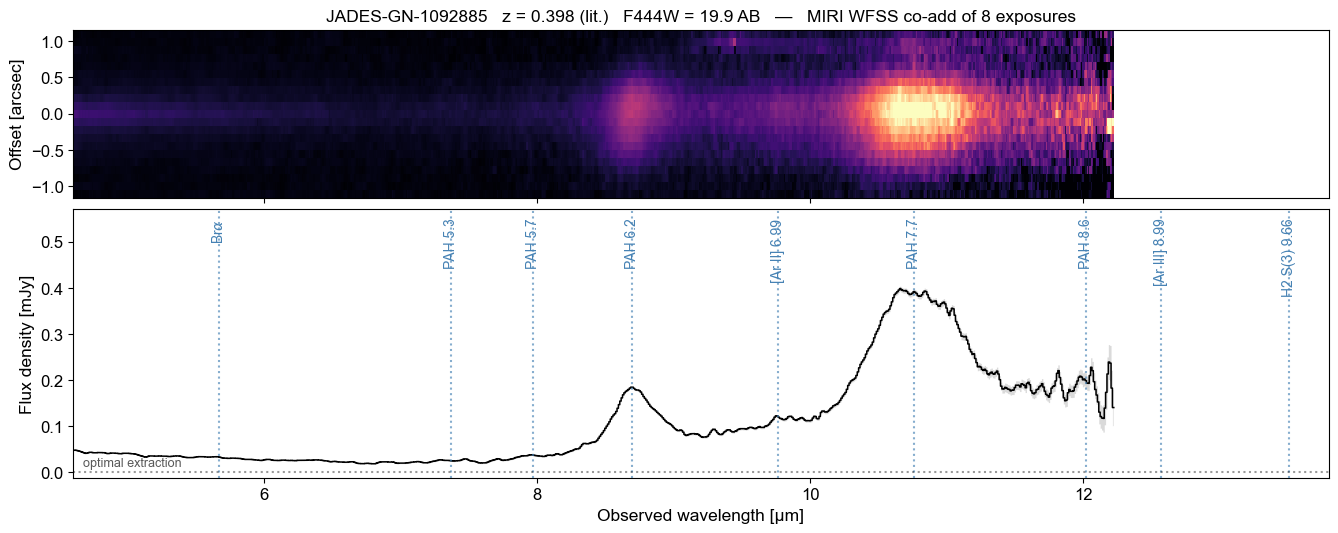

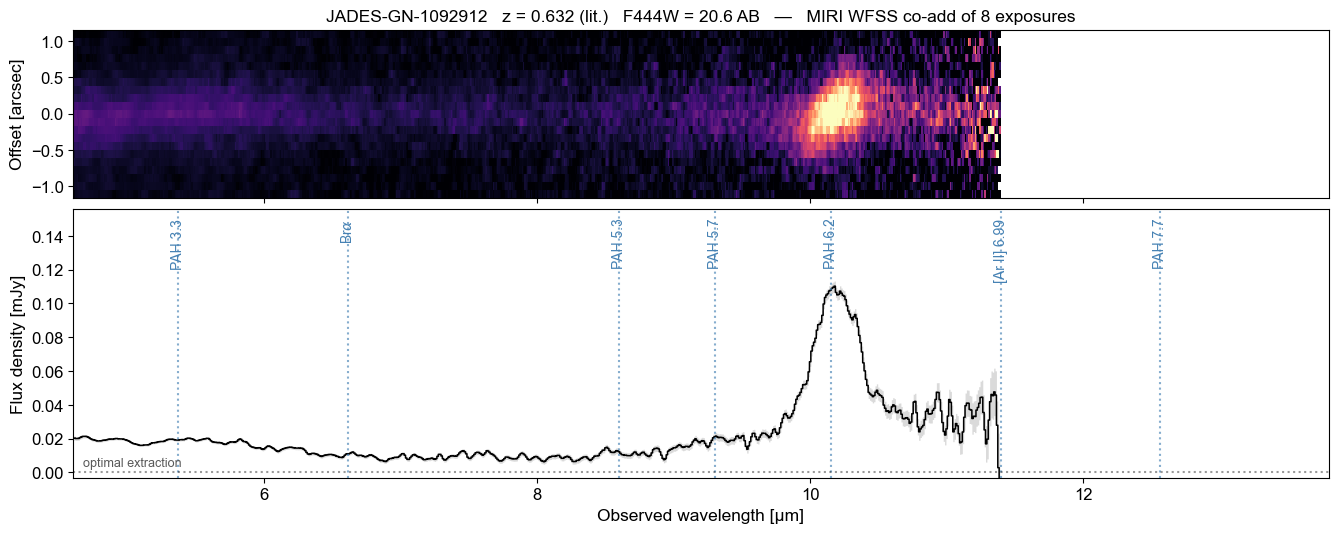

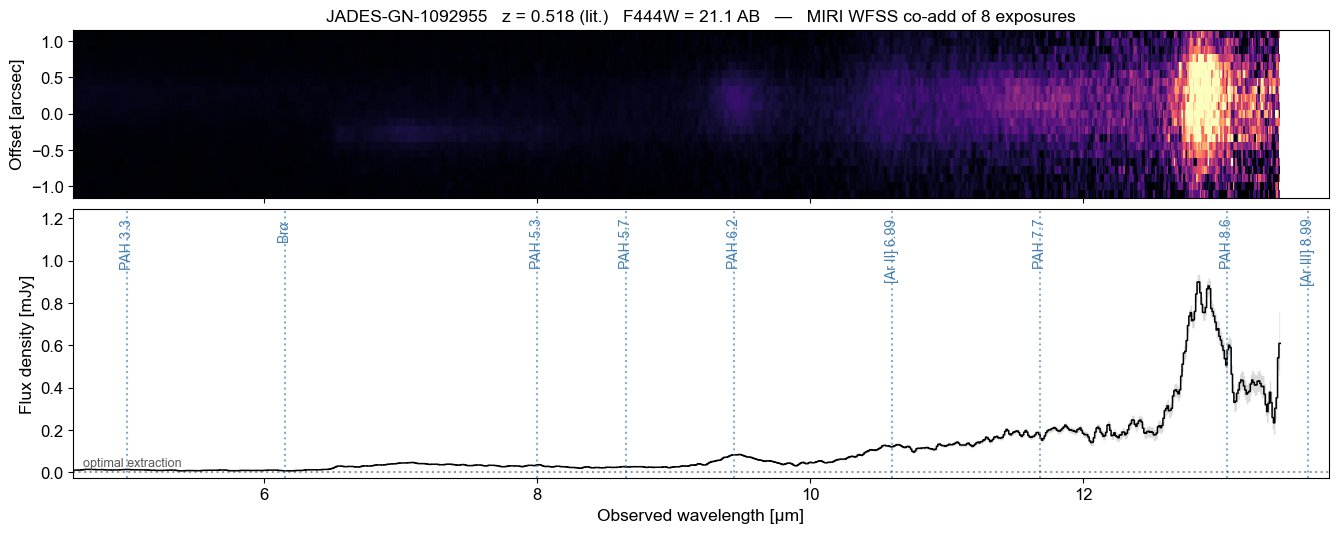

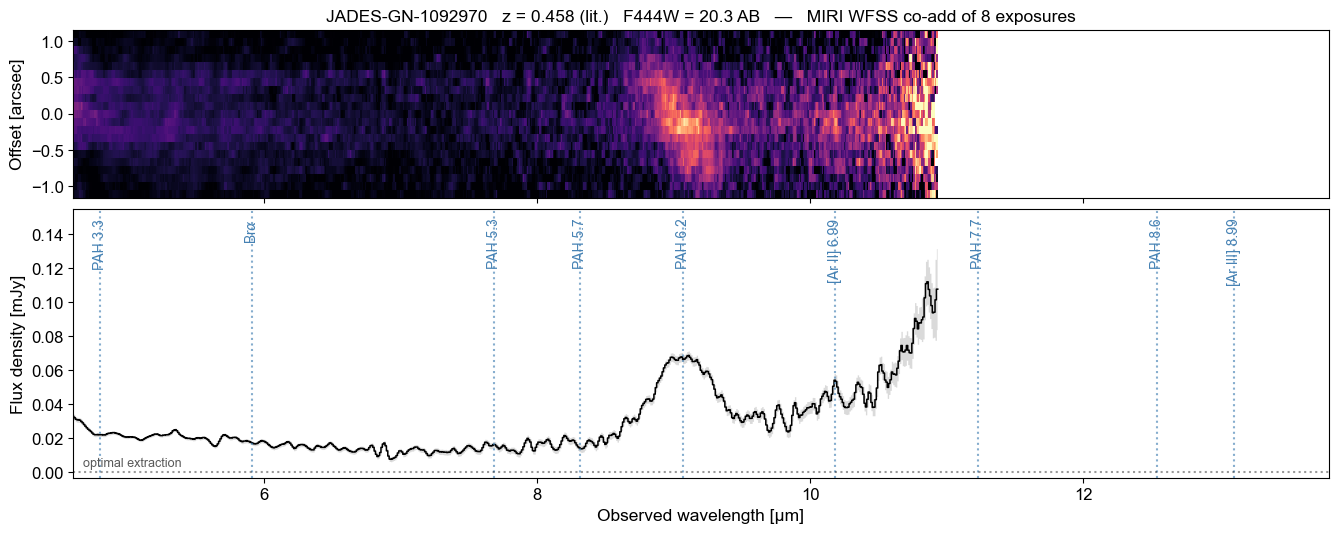

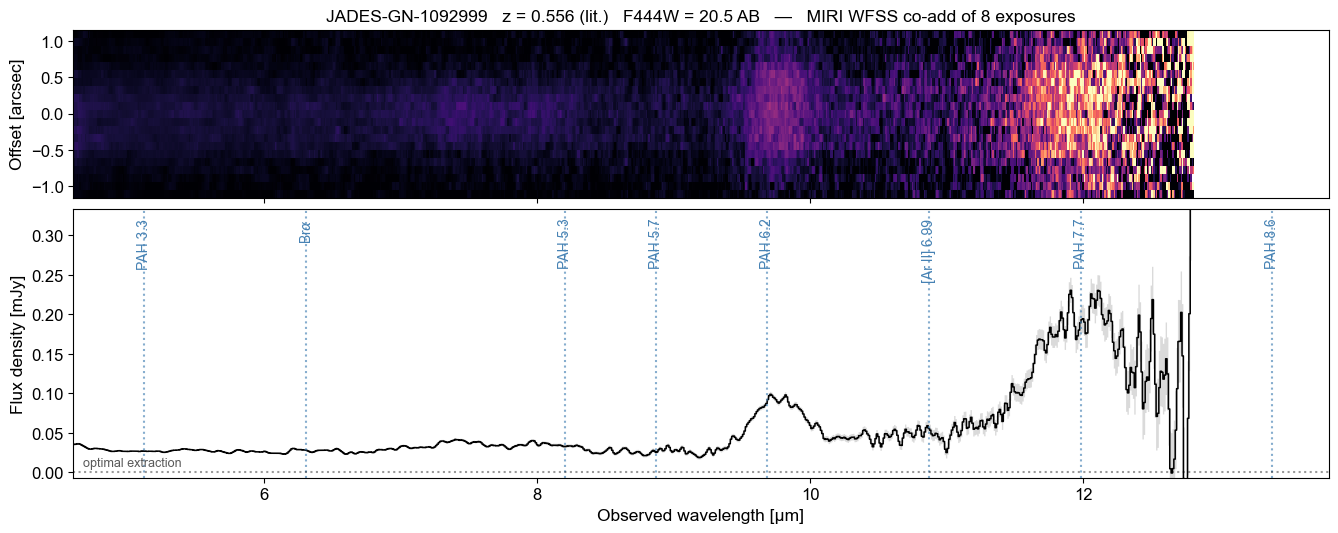

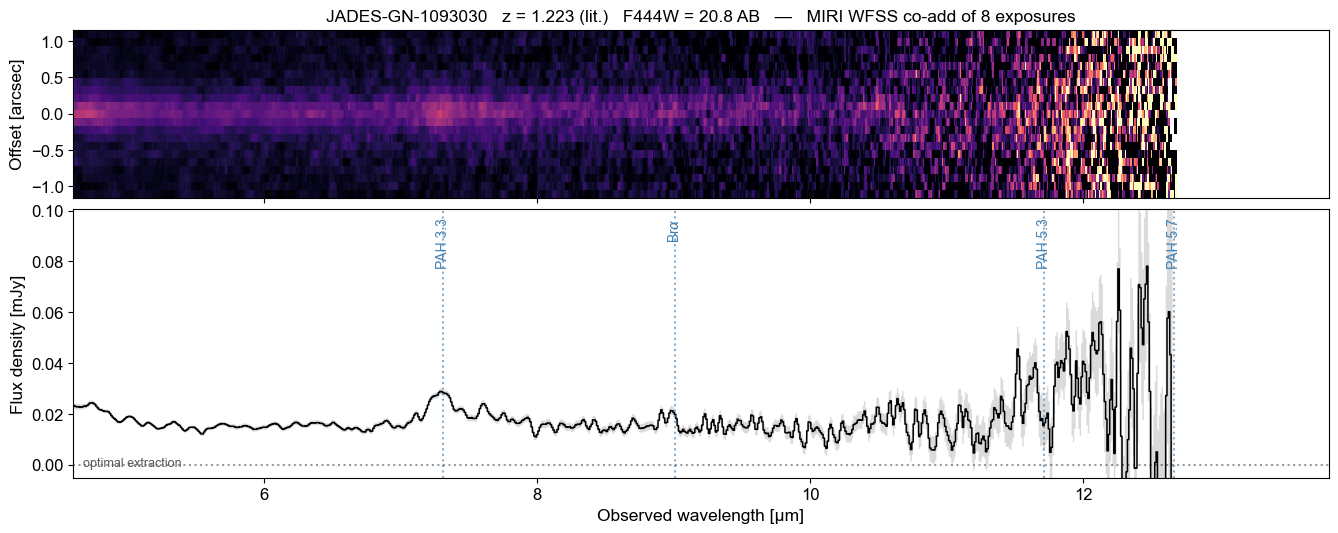


       ID       z Nexp dropPA  S/N opt  S/N box  method   profile
  1085759   1.334    8      0     12.4     10.6  optimal   gaussian(off-center light)
  1092823   0.457    8      0     13.9     12.3  optimal   measured
  1092837   0.458    2      0     71.8     59.1  optimal   measured
  1092885   0.398    8      0     33.2     28.5  optimal   measured
  1092912   0.632    8      0      9.4      8.6  optimal   measured
  1092955   0.518    8      0     15.4     15.6  optimal   measured
  1092970   0.458    8      0     11.0      8.4  optimal   measured
  1092999   0.556    8      0     16.8     13.7  optimal   measured
  1093030   1.223    8      0      9.0      8.1  optimal   measured


In [14]:
SHOW_LINES = [('Pa$\\alpha$', 1.8756), ('PAH 3.3', 3.29),
              ('Br$\\alpha$', 4.052), ('PAH 5.3', 5.27), ('PAH 5.7', 5.70),
              ('PAH 6.2', 6.22), ('[Ar II] 6.99', 6.985), ('PAH 7.7', 7.7),
              ('PAH 8.6', 8.6), ('[Ar III] 8.99', 8.991),
              ('H2 S(3) 9.66', 9.665), ('[S IV] 10.51', 10.511),
              ('PAH 11.3', 11.3), ('H2 S(2) 12.28', 12.279),
              ('PAH 12.7', 12.7), ('[Ne II] 12.81', 12.814)]


def smooth_keepnan(f, k = 3):
    """Boxcar-smooth for display while leaving NaN gaps in place.

    f : 1D array to smooth (NaNs preserved as gaps)
    k : boxcar width [samples]
    """
    fin = np.isfinite(f)
    out = f.copy()
    kern = np.ones(k) / k
    out[fin] = np.convolve(np.nan_to_num(f, nan = 0.0), kern, 'same')[fin] / \
               np.maximum(np.convolve(fin.astype(float), kern, 'same')[fin], 1e-9)
    return out


def plot_spectrum(res, row, f1d, e1d, method, save = None):
    """Atlas-style 2D + 1D figure for one co-added source.

    res    : co-add dict from coadd_source() (uses wave, f2, n)
    row    : catalog row of the source (ID, z_spec, mag444, ...)
    f1d    : adopted 1D flux density on res['wave'] [mJy]
    e1d    : 1-sigma uncertainty of f1d [mJy]
    method : extraction-method label, printed in the figure corner
    save   : output path for a PNG copy (None = display only)
    """
    wave = res['wave']
    zsp = float(row['z_spec'])
    zsrc = str(row['z_source']) if 'z_source' in row.colnames else 'lit.'
    fig = plt.figure(figsize = (13.5, 5.6))
    gs = fig.add_gridspec(2, 1, height_ratios = [1, 1.6], hspace = 0.05,
                          left = 0.06, right = 0.99, top = 0.91, bottom = 0.11)
    ax_2d = fig.add_subplot(gs[0])
    ax_1d = fig.add_subplot(gs[1], sharex = ax_2d)

    yy = (np.arange(res['f2'].shape[1]) - AP_HALF) * PIX_MIRI
    # adaptive stretch: noise-anchored floor, trace-anchored ceiling
    f2 = res['f2']
    med = np.nanmedian(f2)
    sig = 1.4826 * np.nanmedian(np.abs(f2 - med))
    core = f2[:, AP_HALF - 2:AP_HALF + 3]
    peak = np.nanpercentile(core[np.isfinite(core)], 98) \
        if np.isfinite(core).any() else med + 8 * sig
    vmin = med - 1.0 * sig
    vmax = max(med + 8 * sig, min(peak, med + 60 * sig))
    ax_2d.pcolormesh(wave, yy, f2.T, cmap = 'magma', vmin = vmin, vmax = vmax,
                     shading = 'auto', rasterized = True)
    ax_2d.set_ylabel('Offset [arcsec]')
    ax_2d.tick_params(labelbottom = False)
    ax_2d.set_title(f"JADES-GN-{int(row['ID'])}   z = {zsp:.3f} ({zsrc})   "
                    f"F444W = {row['mag444']:.1f} AB   —   MIRI WFSS co-add of "
                    f"{res['n']} exposures", fontsize = 12.5)

    f1s = smooth_keepnan(f = f1d, k = 3)
    ax_1d.fill_between(wave, f1s - e1d, f1s + e1d, color = '0.82', lw = 0,
                       alpha = 0.8, step = 'mid')
    ax_1d.plot(wave, f1s, color = 'k', lw = 1.1, drawstyle = 'steps-mid')
    xlim = (4.6, 13.8)
    inx = np.isfinite(f1s) & (wave >= xlim[0]) & (wave <= xlim[1])
    top = np.nanpercentile(f1s[inx], 99.5) * 1.45
    bot = max(np.nanpercentile(f1s[inx], 2) - 1.5 * np.nanmedian(e1d[inx]),
              -0.12 * top)
    ylim = (min(bot, -0.02 * top), top)
    marks = [(lrest * (1 + zsp), nm) for nm, lrest in SHOW_LINES
             if xlim[0] + 0.12 < lrest * (1 + zsp) < xlim[1] - 0.12]
    lvl, last = 0, -1e9
    for lobs, nm in sorted(marks):
        ax_1d.axvline(lobs, color = 'steelblue', ls = ':', alpha = 0.65)
        lvl = 1 - lvl if (lobs - last) < 0.05 * (xlim[1] - xlim[0]) else 0
        ax_1d.text(lobs, ylim[1] * (0.965 - 0.20 * lvl), nm, rotation = 90,
                   fontsize = 10, ha = 'center', va = 'top', color = 'steelblue')
        last = lobs
    ax_1d.axhline(0, color = 'k', ls = ':', alpha = 0.4)
    ax_1d.set(xlabel = 'Observed wavelength [µm]', ylabel = 'Flux density [mJy]',
              xlim = xlim, ylim = ylim)
    ax_1d.text(0.008, 0.03, f'{method} extraction', transform = ax_1d.transAxes,
               fontsize = 9, color = '0.35', va = 'bottom')
    if save:
        fig.savefig(save, dpi = 150, bbox_inches = 'tight')
    plt.show()


# per-source overrides — GN 1085759: a second bright component (possibly an
# imaging component merging with the galaxy itself) sits ~1" off the target;
# pin both the co-add recentering and the profile alignment to the catalog
# position so the extraction cannot walk onto it
FIXED_POSITION_IDS = {1085759}


def extract_one(row):
    """Co-add, extract, plot, and save one catalog source (also Pool-friendly).

    row : catalog row (ID, RA, DEC, z_spec, mag444, ...); returns the summary
          tuple for the table below, or None if no usable co-add exists
    """
    gid = int(row['ID'])
    fixed = gid in FIXED_POSITION_IDS
    res = coadd_source(name = f'JADES-GN-{gid}', ra = float(row['RA']),
                       dec = float(row['DEC']), exps = cov_map[gid],
                       recenter = RECENTER and not fixed, pa_group = PA_GROUP)
    if res is None:
        print(f'JADES-GN-{gid}: not enough usable exposures'); return None
    P, plab = profile_from_coadd(res)
    fopt, eopt, fbox, ebox, snr_o, snr_b, apc = extract_1d(res = res, P = P,
                                                           align = ALIGN_PROFILE and not fixed,
                                                           box_half = BOX_HALF)
    # adopt the optimal extraction unless the boxcar S/N is decisively
    # (>5%) higher: at a near-tie the two estimators should agree, and a
    # large flux disagreement between them signals a mismatched or
    # contaminated profile — where the Horne amplitude is the more robust
    # flux for the cataloged source
    if np.isfinite(snr_o) and snr_b <= 1.05 * snr_o:
        f1d, e1d, falt, ealt, method = fopt, eopt, fbox, ebox, 'optimal'
    else:
        f1d, e1d, falt, ealt, method = fbox, ebox, fopt, eopt, f'boxcar(±{BOX_HALF * PIX_MIRI:.2f}")'
    plot_spectrum(res = res, row = row, f1d = f1d, e1d = e1d, method = method,
                  save = PRODUCTS / f'spec_GN_{gid}.png')
    t = Table({'wave_um': res['wave'], 'flux_mJy': f1d, 'err_mJy': e1d,
               'flux_alt_mJy': falt, 'err_alt_mJy': ealt})
    t.meta.update(dict(ID = gid, field = 'GN', RA = float(row['RA']), DEC = float(row['DEC']),
                       z_spec = float(row['z_spec']),
                       z_source = str(row['z_source']) if 'z_source' in cat.colnames else 'lit.',
                       n_exp = res['n'], mag444 = float(row['mag444']), method = method,
                       profile = plab, pa_disp_deg = res['pa_disp']))
    t.write(PRODUCTS / f'spec_GN_{gid}.ecsv', format = 'ascii.ecsv', overwrite = True)
    return (gid, float(row['z_spec']), res['n'], res['n_drop_pa'],
            snr_o, snr_b, method, plab)


# serial by default — the figures render inline as the loop progresses:
summary = [extract_one(row) for row in cat]

# ## uncomment to extract the whole catalog with n_proc processes instead
# ## (Linux; figures are then only saved to products/, not shown inline):
# with Pool(min(n_proc, len(cat))) as pool:
#     summary = pool.map(extract_one, cat)

summary = [s for s in summary if s is not None]

print(f'\n{"ID":>9s} {"z":>7s} {"Nexp":>4s} {"dropPA":>6s} {"S/N opt":>8s} '
      f'{"S/N box":>8s}  method   profile')
for gid, z, n, nd, so, sb, m, pl in summary:
    print(f'{gid:9d} {z:7.3f} {n:4d} {nd:6d} {so:8.1f} {sb:8.1f}  {m}   {pl}')

## Step 11 — Caveats & tips

* **Response validity**: fR(λ) is defined over 4.46–13.81 µm; the co-add grid spans
  4.6–13.8 µm and S/N is best at 5–13 µm. Blueward of 7.44 µm the *shape* comes from
  the stellar ensemble (~5%); treat fine continuum structure there accordingly.
* **The blue end (≲5.1 µm) deserves extra caution**: the prism dispersion is lowest
  there (~0.09–0.11 µm per detector row, so 4.6–5.1 µm spans only ~5 rows), the bluest
  response bins (4.46–4.7 µm) are constrained by few ensemble samples, and the
  wavelength solution is extrapolated blueward of its ~5.3 µm anchors. The fluxes are
  calibrated, but expect coarse sampling and wavelength errors up to ~1 resolution
  element.
* **Wavelength coverage depends on detector position**: the red end of a trace
  (dy → −262 px) runs off the detector for sources at y₀ ≲ 280 — e.g. GN 1092912
  (y₀ ≈ 140) truncates near 11.6 µm while GN 1092837 (y₀ ≈ 810) reaches 13.8 µm. The
  blue end (dy = +150) similarly needs y₀ ≲ 870. Plan source selection accordingly.
* **Saturation**: the brightest mid-IR sources (≲ 14–15 AB at F560W) saturate the core
  of their traces; saturated pixels carry DQ bit 2 and are masked, but strong
  charge-spill residuals can survive — inspect the 2D co-add before trusting the 1D.
* **Crowding/contamination**: there is **no contamination model** — every source in the
  field disperses over ±260 px in y. Check the 2D cutout for overlapping traces
  (they appear as offset streaks in the cross-dispersion direction) and treat
  single-row features cautiously. GN 1085759 in this very example is a worked case: a
  bright second component (possibly an imaging component merging with the galaxy
  itself) sits ~1″ off the target position. The profile guard falls back to the
  centered Gaussian (`gaussian(off-center light)`), and the catalog loop pins this
  source to its catalog position outright (`FIXED_POSITION_IDS` in step 10 —
  recentering and profile alignment disabled), so the extraction cannot walk onto
  the off-center light.
* **Extended sources**: the Gaussian default profile and the ±0.33″ boxcar are tuned to
  marginally resolved galaxies. For clearly extended sources, supply an image-collapsed
  profile (step 9 hook), widen the boxcar, and note that fR(λ) is calibrated for
  point-source-weighted apertures — extended-source systematics of several % can remain.
* **Astrometry**: catalog→WCS offsets up to a few px are absorbed by the two-pass
  recentering (step 8) and the profile alignment (step 9); for sources near the margins
  the recenter can fail — check the reported centroids if a trace looks decentered.
* **Barycentric correction**: wavelengths are vacuum, in the observed frame of each
  exposure epoch; the co-add mixes epochs (here ΔV ≲ 30 km/s, well below the wavelength
  accuracy). For kinematic work, correct each exposure with its `VELOSYS` before
  co-adding.
* **Background residuals**: the sky-v5 chain (additive defect map + scaled master sky +
  per-row de-banding) leaves low-order 2D sky residuals at the sub-percent level in
  unlucky frames; the per-row local background in `rectify()` removes what matters for
  compact sources. Mode B (PCA) helps full-field work (e.g. extended line maps) — but
  difference it against mode A before trusting compact faint sources.
* **Pipeline versions**: the lv1.5 step consumes standard `rate` files — re-runs of the
  STScI level-1 pipeline (new reference files, snowball handling, …) propagate directly.

For the calibration derivation, validation, and the full GOODS-N/GOODS-S/LMC atlas, see
**Sun (2026)** and the repository README. Questions and bug reports: please open a
GitHub issue or email sunfengwu在westlake.edu.cn.

In [15]:
# reproducibility record
import astropy, scipy, sys
print('python ', sys.version.split()[0])
for mod in (np, scipy, astropy):
    print(f'{mod.__name__:9s}', mod.__version__)
try:
    import jwst, crds
    print('jwst     ', jwst.__version__)
    print('crds     ', crds.__version__)
    print('CRDS_CONTEXT =', os.environ.get('CRDS_CONTEXT', '(latest)'))
except ImportError:
    pass

python  3.11.12
numpy     1.26.4
scipy     1.17.1
astropy   7.0.1
jwst      1.18.0
crds      12.1.4
CRDS_CONTEXT = (latest)
